In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [1]:
from datetime import datetime
from getpass import getpass

rdm_url = 'https://test.rdm.example.com/'
idp_name_1 = 'GakuNin RDM IdP'
idp_username_1 = None
idp_password_1 = None
s3_access_key_2 = None
s3_secret_access_key_2 = None
s3_endpoint_2 = 'test.rdm.example.com'
s3_test_bucket_name_2 = 'e2etest-virginia1'
s3_access_key_1 = None
s3_secret_access_key_1 = None
s3_endpoint_1 = 'htest.rdm.example.com'
s3_test_bucket_name_1 = 'test-bucket'
enable_52gb_file_upload = False
enable_1gb_file_upload = True
skip_130mb_upload = False
default_result_path = None
close_on_fail = False
transition_timeout = 10000
s3compat_type_name_2 = 'Wasabi'
s3compat_type_name_1 = 'SAKURA Cloud'
skip_failed_test = True
skip_preview_check = False
skip_too_many_files_check = False
exclude_notebooks = []

target_storage_name = 'S3 Compatible Storage (SigV4)'
target_storage_id = 's3compatsigv4'
rdm_project_prefix = 'TEST-{}-{}'.format(target_storage_id.upper(), datetime.now().strftime('%Y%m%d-%H%M%S'))

In [2]:
# 設定例:
# Account #1: play.min.io (MinIO デモサーバー)
# Account #2: AWS S3 (ap-northeast-1)


In [3]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))


(8, 20)

In [ ]:
if s3_access_key_1 is None:
    s3_access_key_1 = input(prompt=f'{target_storage_name} Access Key #1')
if s3_secret_access_key_1 is None:
    s3_secret_access_key_1 = getpass(prompt=f'{target_storage_name} Secret Access Key #1')
if s3_endpoint_1 is None:
    s3_endpoint_1 = input(prompt=f'{target_storage_name} Endpoint #1')
if s3_test_bucket_name_1 is None:
    s3_test_bucket_name_1 = input(f'{target_storage_name} Bucket Name #1')
(s3_access_key_1, s3_endpoint_1, s3_test_bucket_name_1)


In [ ]:
# S3認証キー #2 は #1 と異なるアカウントのものである必要あり
if s3_access_key_2 is None:
    s3_access_key_2 = input(prompt=f'{target_storage_name} Access Key #2')
if s3_secret_access_key_2 is None:
    s3_secret_access_key_2 = getpass(prompt=f'{target_storage_name} Secret Access Key #2')
if s3_endpoint_2 is None:
    s3_endpoint_2 = input(prompt=f'{target_storage_name} Endpoint #2')
if s3_test_bucket_name_2 is None:
    s3_test_bucket_name_2 = input(f'{target_storage_name} Bucket Name #2')
(s3_access_key_2, s3_endpoint_2, s3_test_bucket_name_2)


In [6]:
if s3compat_type_name_1 is None:
    s3compat_type_name_1 = input(prompt=f'{target_storage_name} Service Type #1 (e.g. MinIO, Wasabi)')
if s3compat_type_name_2 is None:
    s3compat_type_name_2 = input(prompt=f'{target_storage_name} Service Type #2 (e.g. MinIO, Wasabi)')
(s3compat_type_name_1, s3compat_type_name_2)


('SAKURA Cloud', 'Wasabi')

In [7]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir


'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1'

# GakuNinRDM 総合テスト [S3 Compatible Storage (SigV4)]

- サブシステム名: ログイン
- ページ/アドオン: トップページ
- 機能分類: ストレージ制御確認
- シナリオ名: *
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM)

In [8]:
(target_storage_id, target_storage_name)


('s3compatsigv4', 'S3 Compatible Storage (SigV4)')

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

In [9]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)


('20260213-125909',
 '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpssqw1zey')

Start epoch: 1770955150.133213 seconds


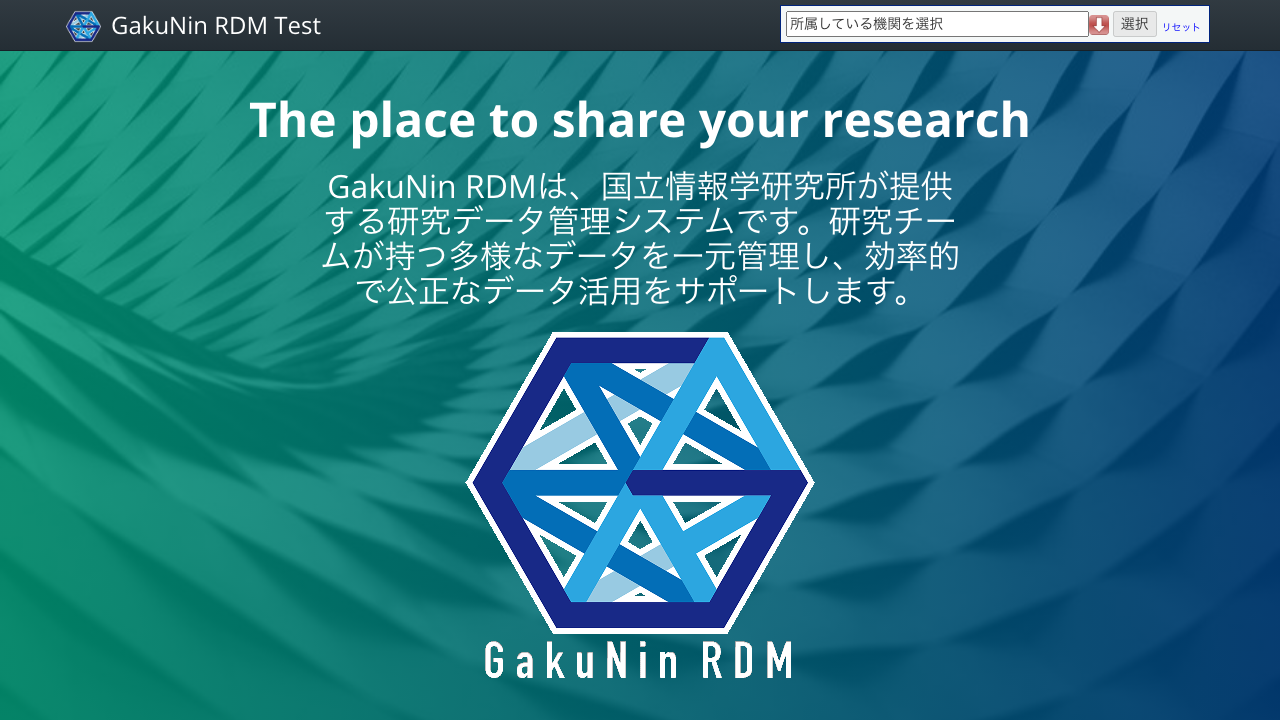

In [10]:
import time

async def _step(page):
    await page.goto(rdm_url)

    # 同意する ボタンが現れるまで待つ
    await expect(page.locator('//button[text() = "同意する"]')).to_be_visible(timeout=transition_timeout)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)


## ログイン情報を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1770955152.461762 seconds


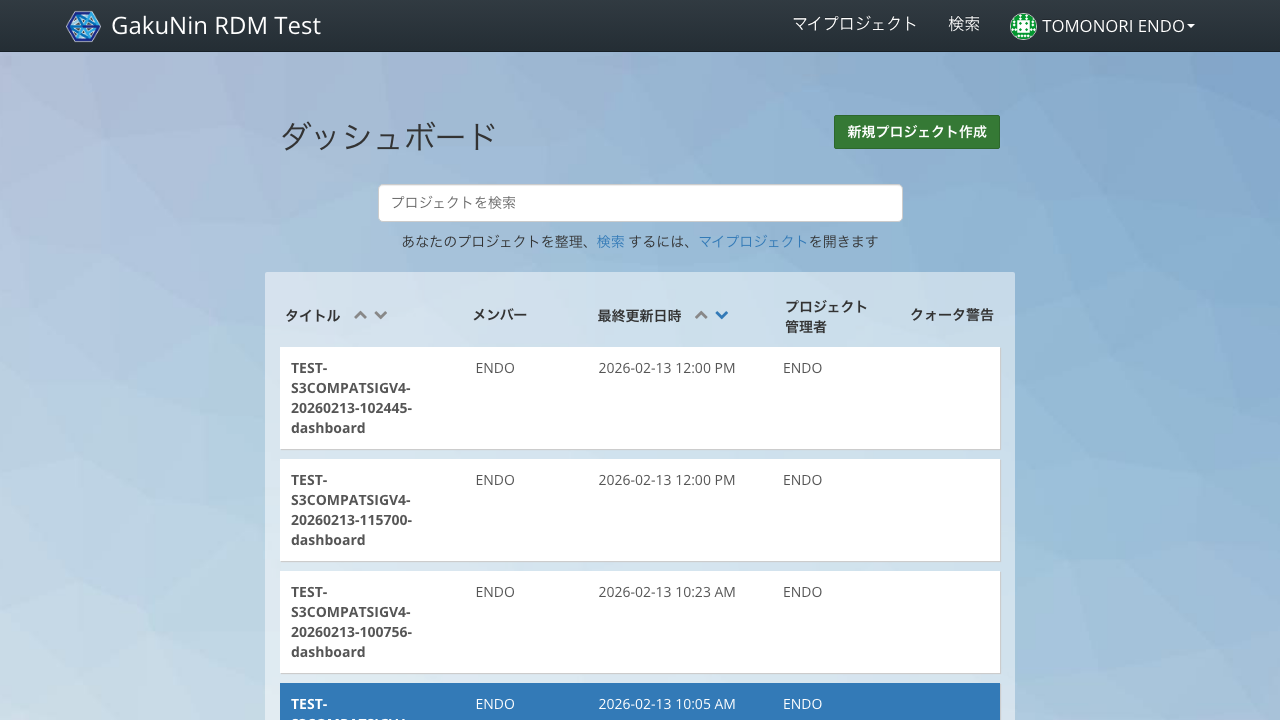

In [11]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## ユーザーメニューから「設定」を選択する

Start epoch: 1770955161.5313752 seconds


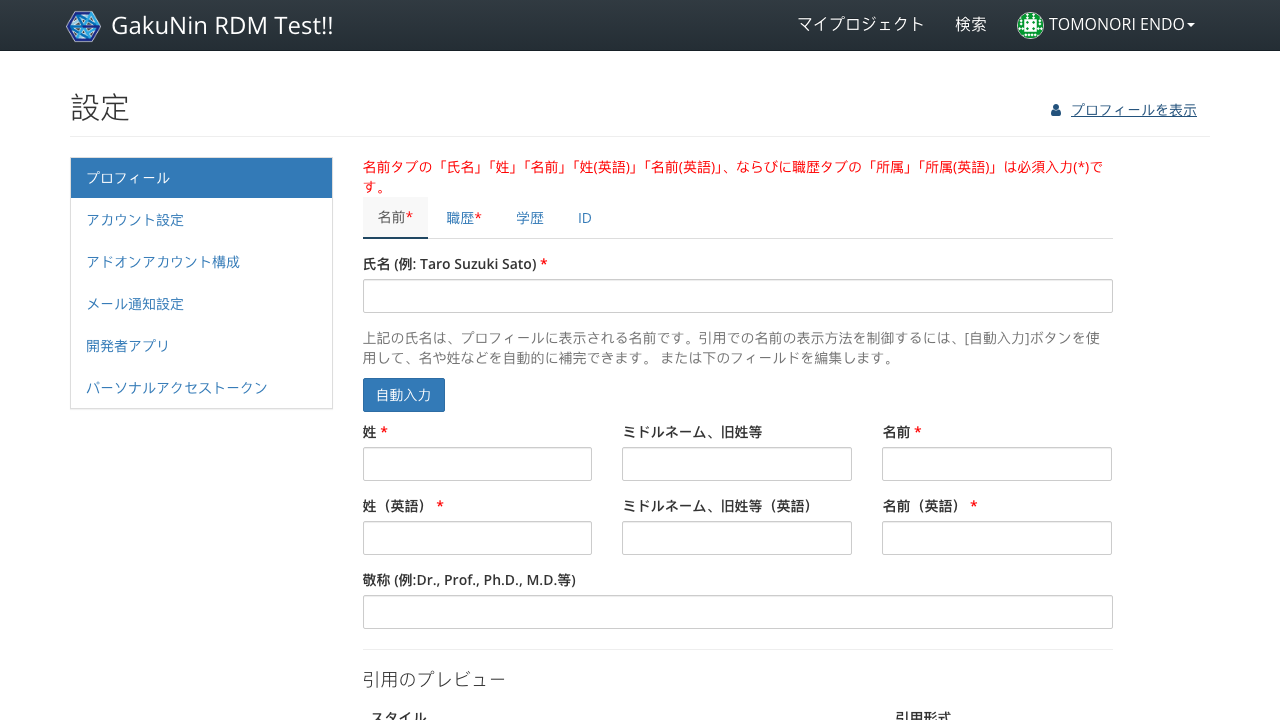

In [12]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@data-analytics-name="Settings"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンアカウント構成」を選択する

Start epoch: 1770955162.489511 seconds


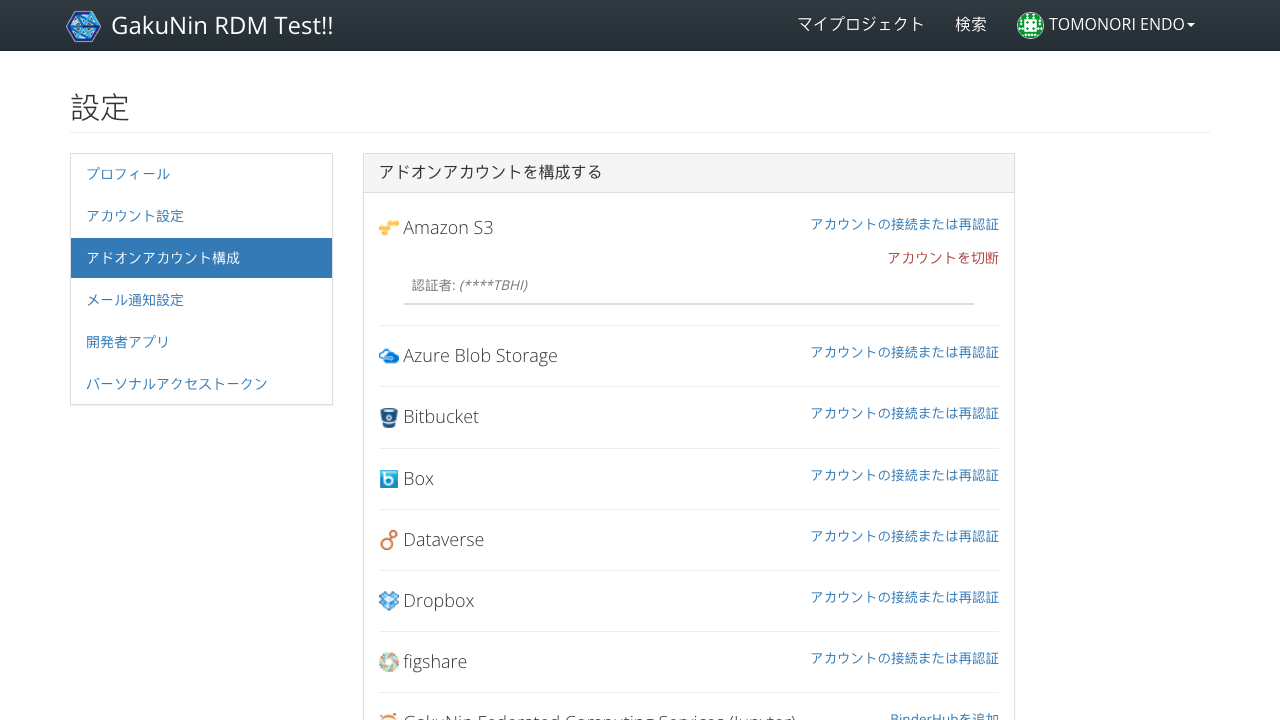

In [13]:
import traceback

has_connections = False

async def _step(page):
    global has_connections
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    # 30秒以内に「アカウントを切断」が1つ以上表示されるかを確認
    try:
        await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
        has_connections = True
    except:
        print('Ignored')
        traceback.print_exc()
        has_connections = False

await run_pw(_step)


## (「アカウントを切断」が対象ストレージに表示されている場合)すべての「アカウントを切断」をクリックし、「Disconnect」をクリックする



Start epoch: 1770955165.160515 seconds
Disconnecting...
Ignored


Traceback (most recent call last):
  File "/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/ipykernel_42925/3891158014.py", line 18, in _step
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/playwright/async_api/_generated.py", line 20255, in to_be_visible
    await self._impl_obj.to_be_visible(visible=visible, timeout=timeout)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/playwright/_impl/_assertions.py", line 763, in to_be_visible
    await self._expect_impl(
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/playwright/_impl/_assertions.py", line 83, in _expect_impl
    raise AssertionError(
AssertionError: Locator expected to be visible
Actual value: <element(s) not found> 
Call log:
  - Expect "to_be_visible" with timeout 30000ms
  - waiting for locator("//*[@src=\"/stat

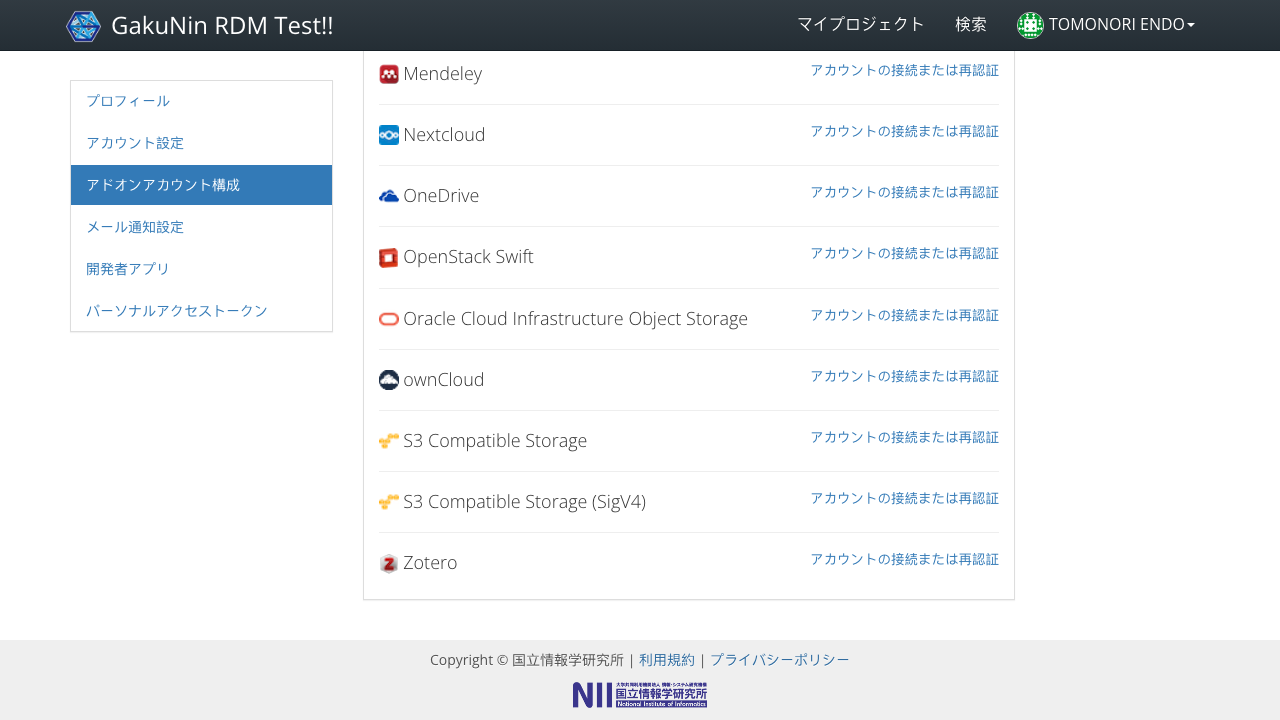

In [14]:
async def _step(page):
    if not has_connections:
        return
    try:
        await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
    except:
        print('Ignored')
        traceback.print_exc()
        return
    while True:
        print('Disconnecting...')
        await page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]').click()
        await page.locator('.bootbox-confirm .btn-danger').click()
        # 30秒以内に「アカウントを切断」が表示されれば繰り返し
        try:
            # 前のものが消えるまで待つ...
            time.sleep(3)
            await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
        except:
            print('Ignored')
            traceback.print_exc()
            break
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)


## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1770955199.1764631 seconds


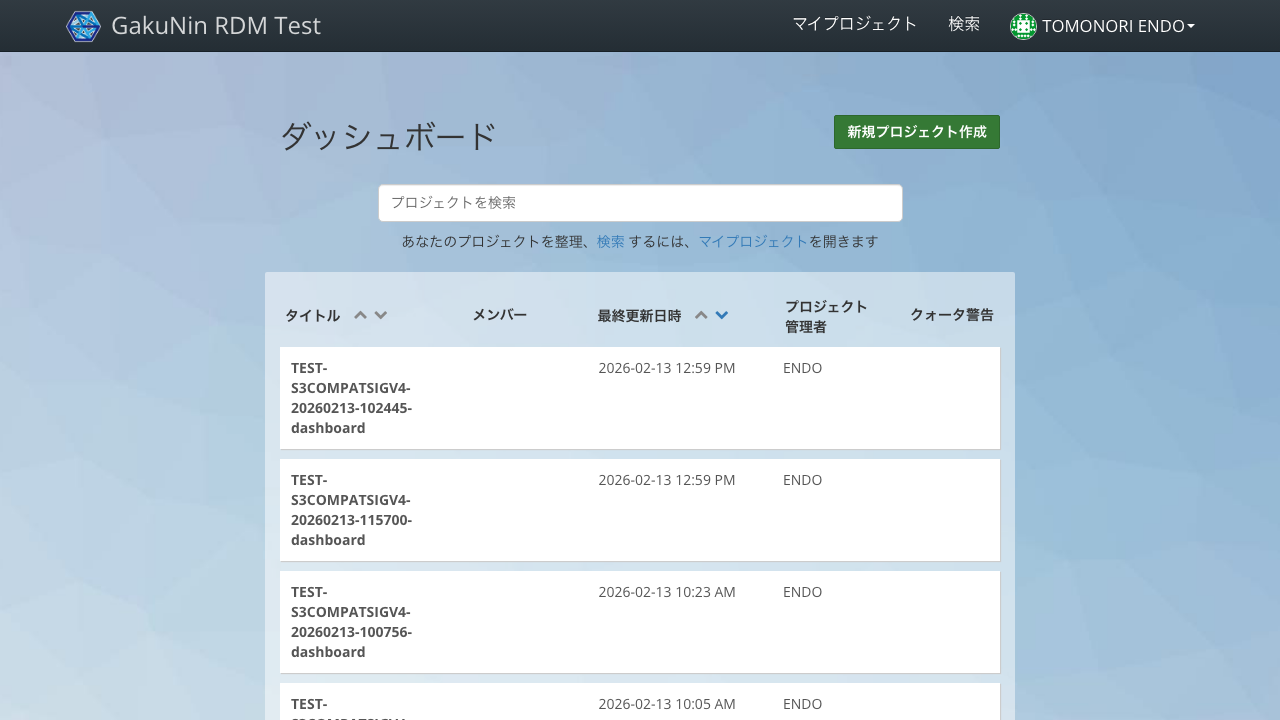

In [15]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TEST-対象ストレージ-YYYYMMDD-HHMMSS-dashboard」プロジェクトを作成する

Start epoch: 1770955201.4625762 seconds


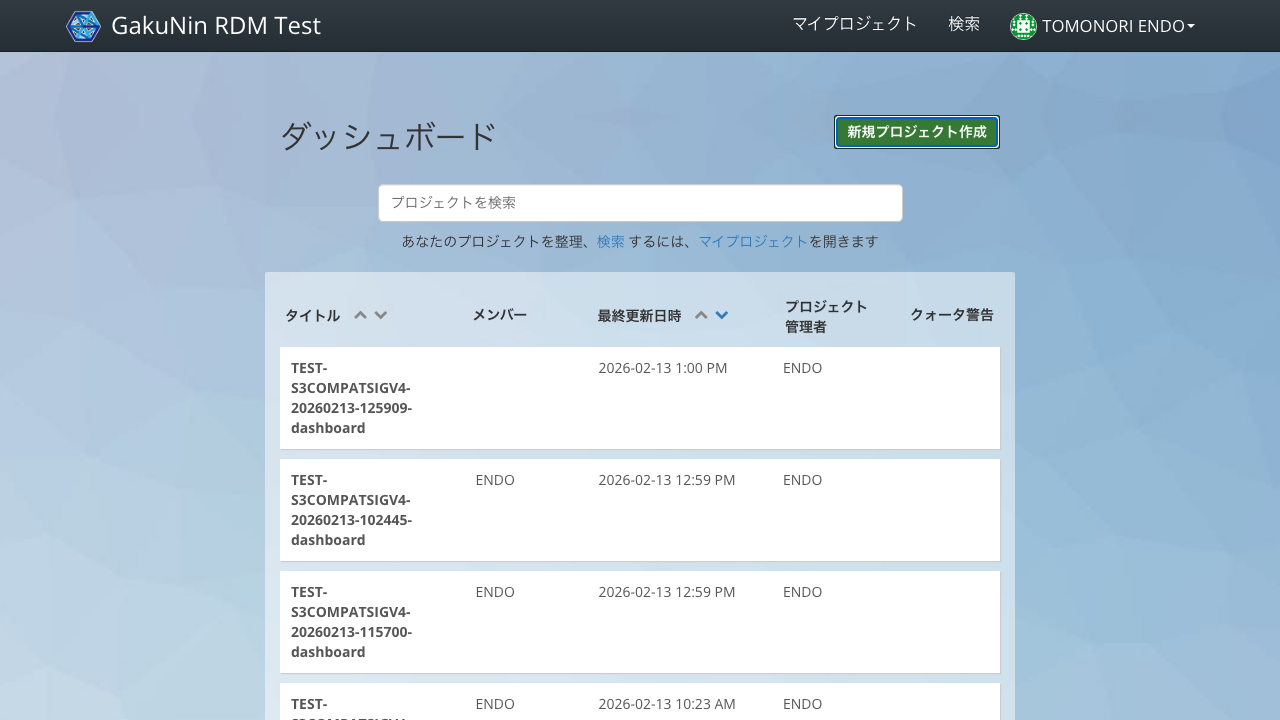

In [16]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-dashboard', transition_timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

In [18]:
async def _step(page):
    await page.reload()
    project_item = page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-dashboard"]')
    await expect(project_item).to_be_visible(timeout=transition_timeout)
    await project_item.click()

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1770956389.1399949 seconds


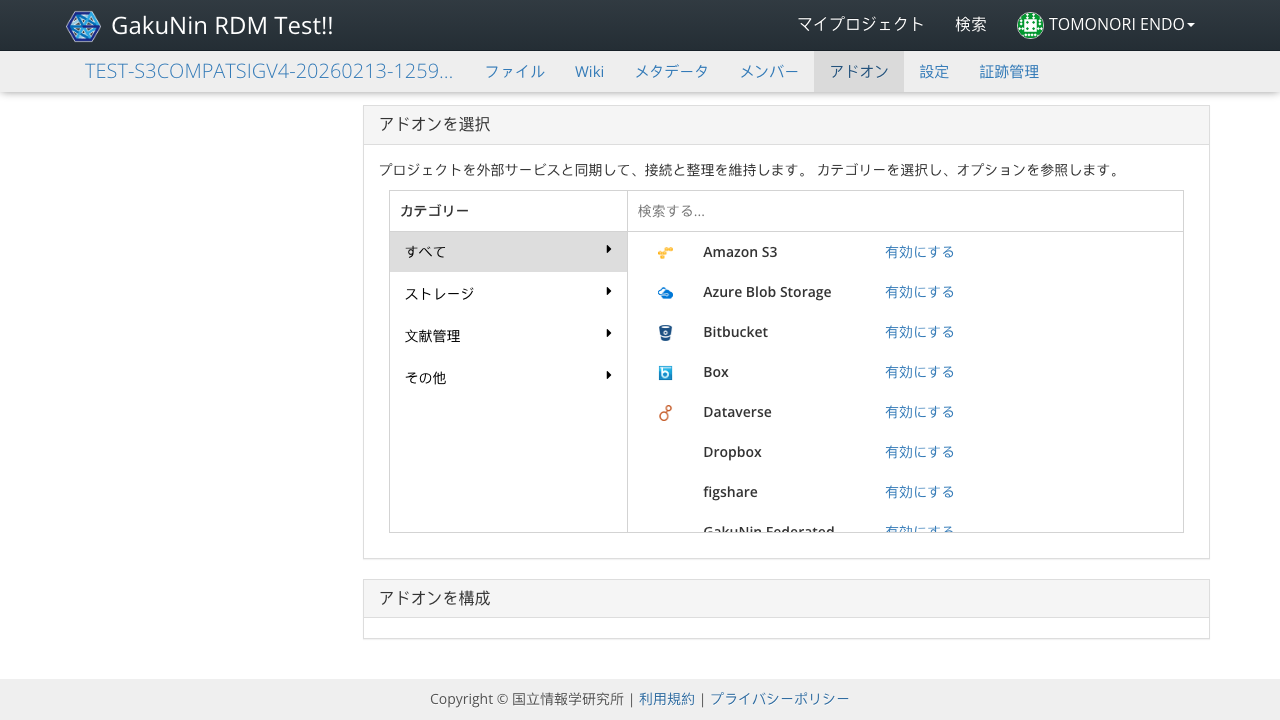

In [19]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1770956393.954144 seconds


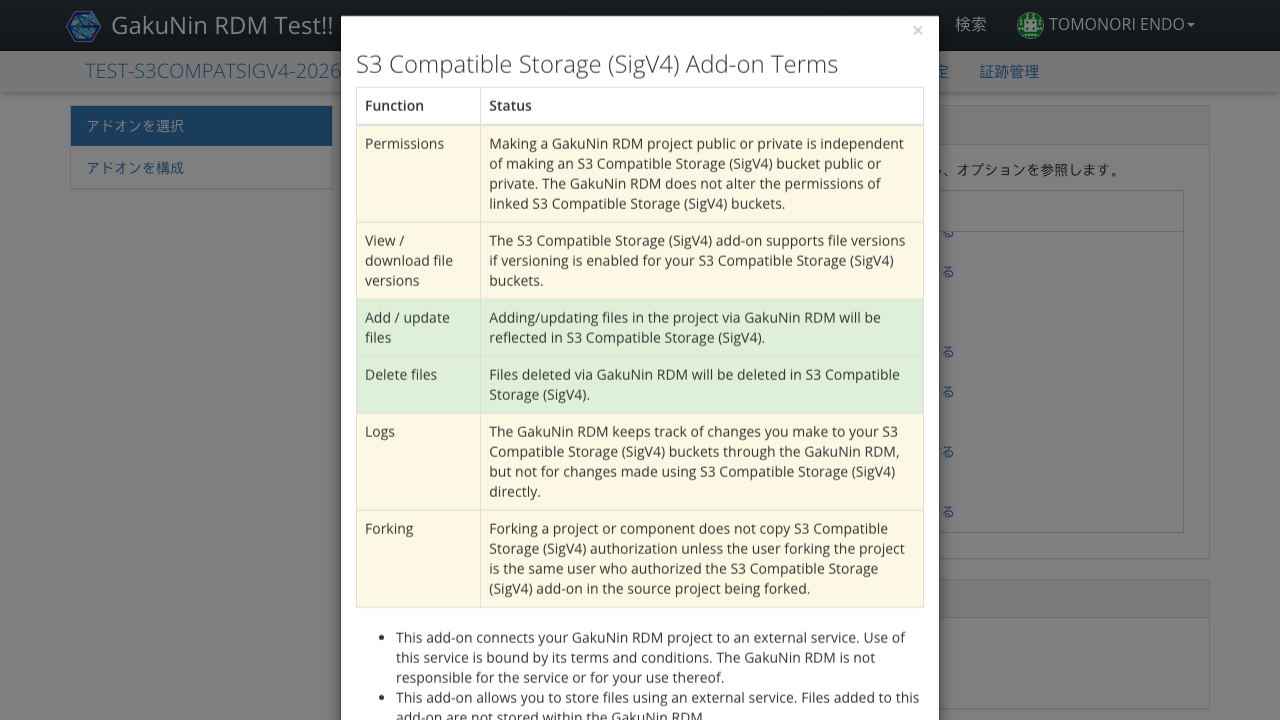

In [20]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()

    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「確認」をクリックする

Start epoch: 1770956395.532573 seconds


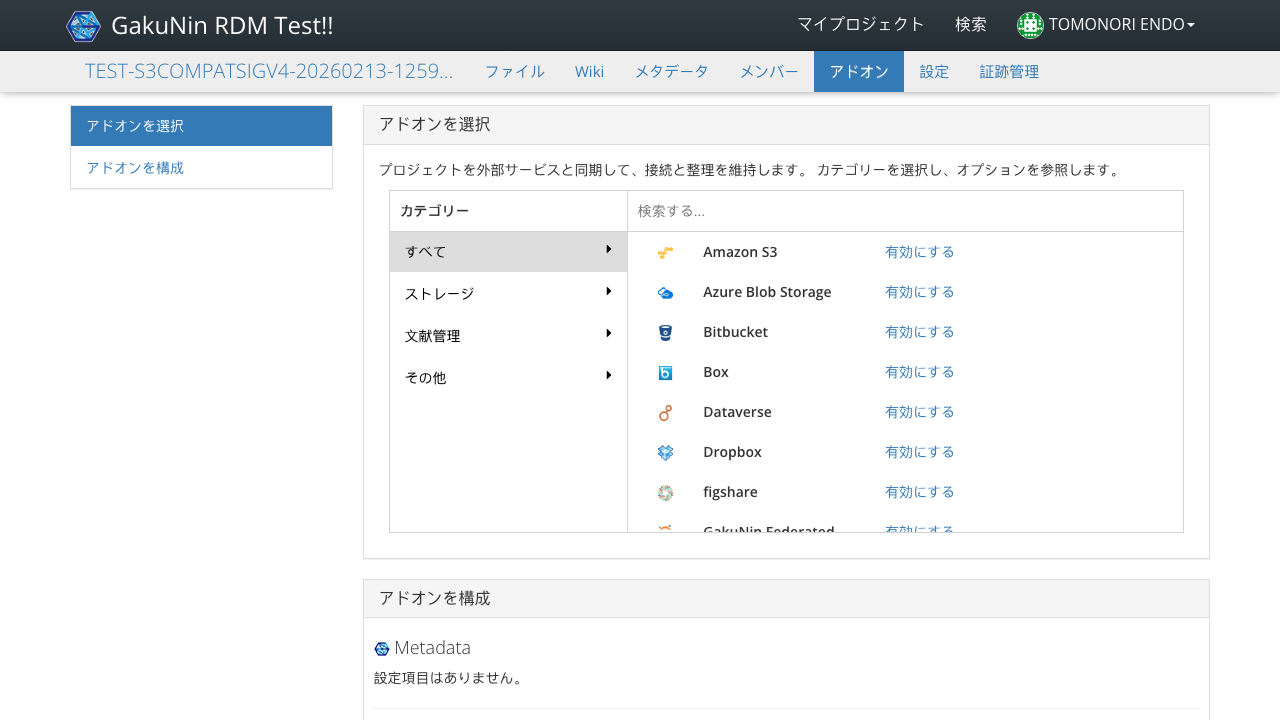

In [21]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()

    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "アカウントに接続する")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アカウントに接続する」リンクをクリックする

Start epoch: 1770956397.88235 seconds


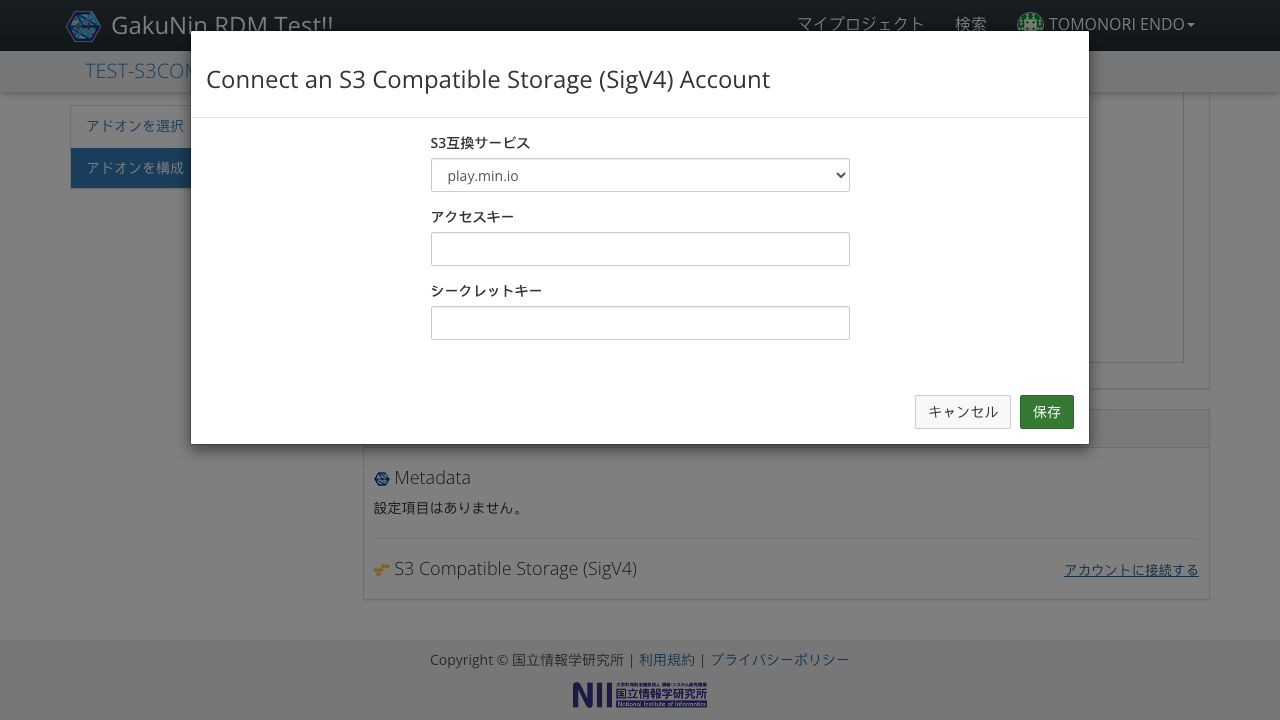

In [22]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "アカウントに接続する")]').click()

    await expect(page.locator(f'#{target_storage_id}InputCredentials .btn-success')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## S3互換サービスを選択し、アクセスキーとシークレットキー(1つ目)を入力する

In [ ]:
async def _step(page):
    # S3 Compatible Service のドロップダウンからサービスを選択
    await page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//select[@id = "selected_service"]').select_option(s3compat_type_name_1)
    access_key_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "access_key"]')
    secret_access_key_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "secret_key"]')
    #endpoint_url_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "endpoint_url"]')
    await access_key_field.fill(s3_access_key_1)
    await secret_access_key_field.fill(s3_secret_access_key_1)
    #await endpoint_url_field.fill(s3_endpoint_1)

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770956404.558131 seconds


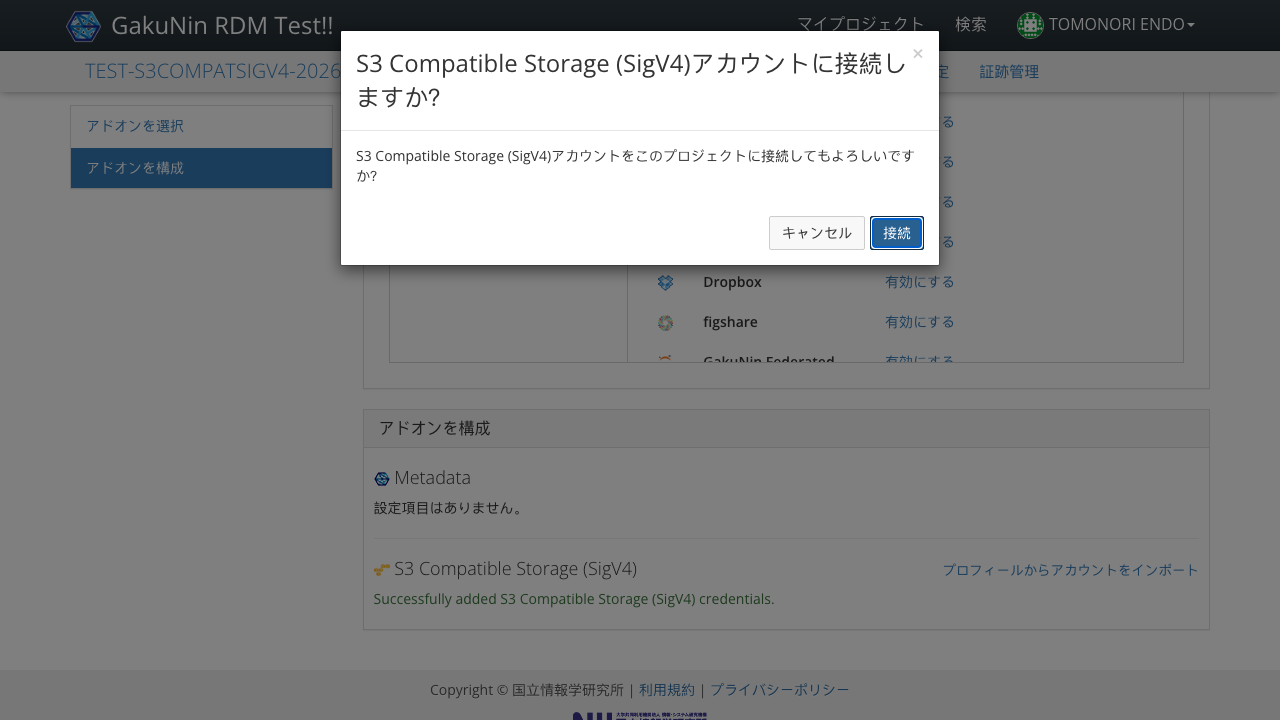

In [24]:
async def _step(page):
    await page.locator(f'#{target_storage_id}InputCredentials .btn-success').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「接続」をクリックする

Start epoch: 1770956407.739486 seconds


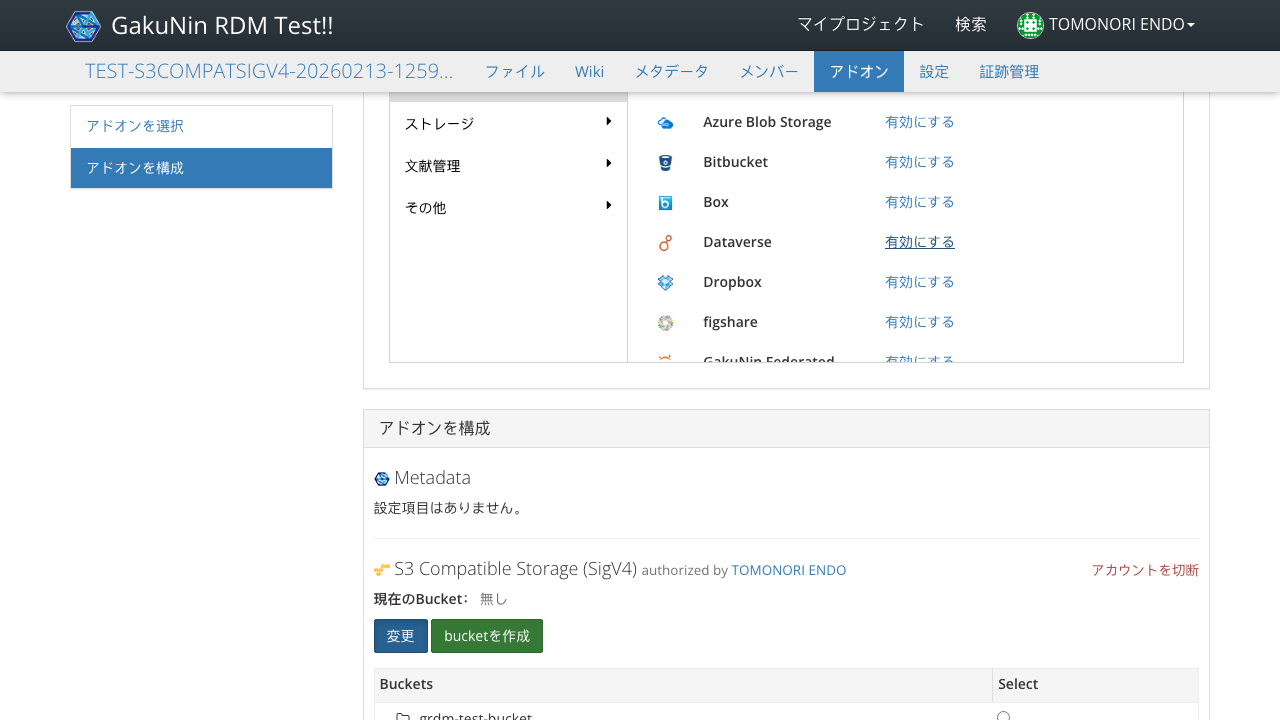

In [25]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//button[@id = "newBucket"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 指定されたバケットを選択する

Start epoch: 1770956411.378805 seconds


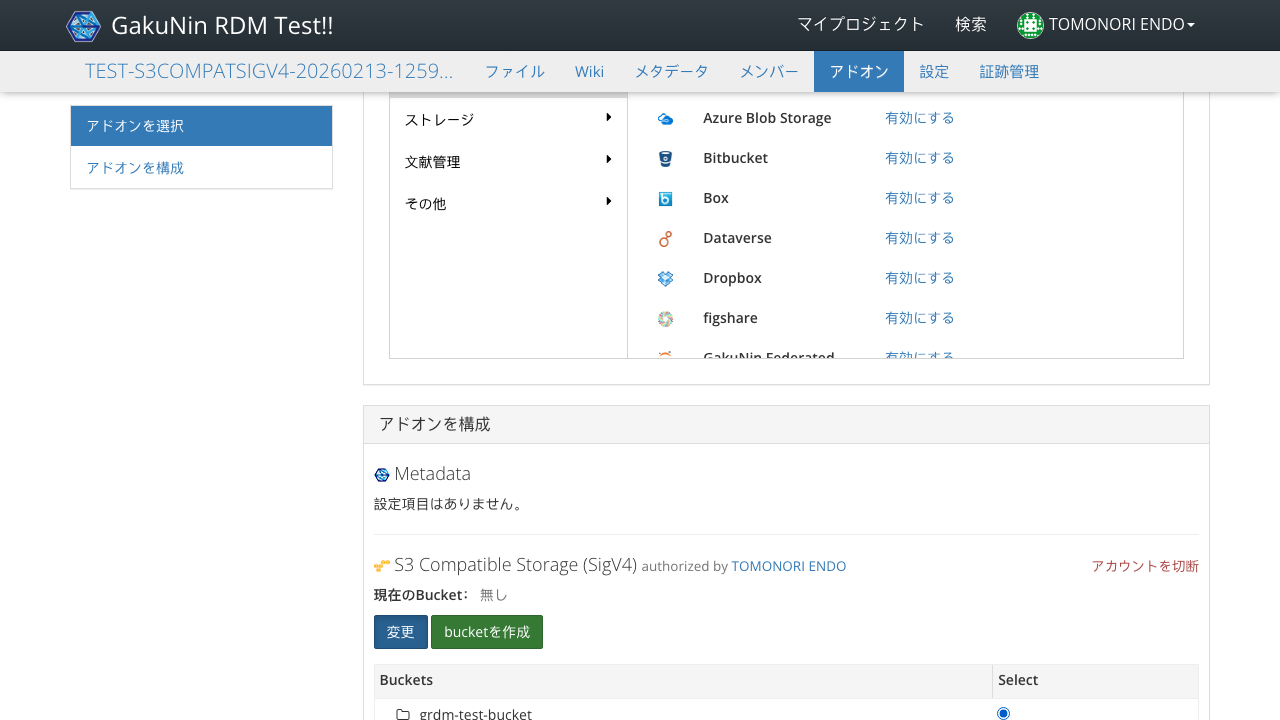

In [26]:
async def _step(page):
    await page.locator(f'//span[text() = "{s3_test_bucket_name_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770956416.915817 seconds


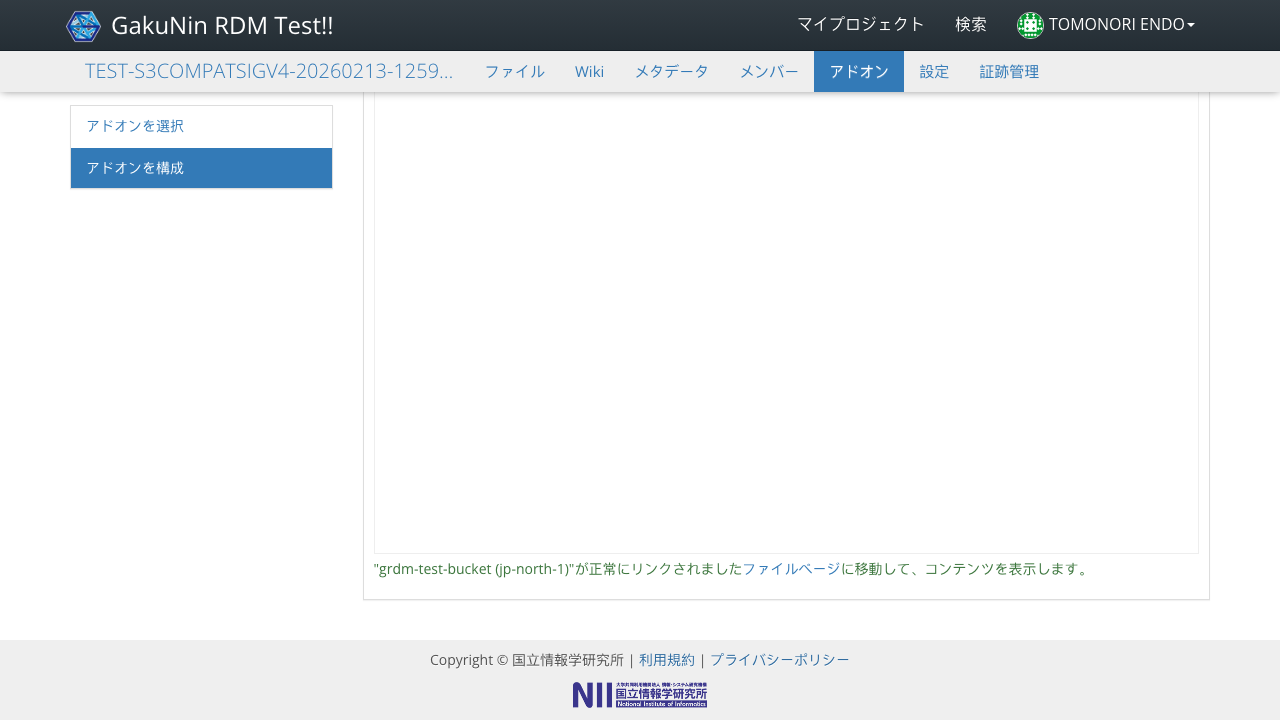

In [27]:
import asyncio

async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    await asyncio.sleep(3)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)


## 「ファイルページ」リンクをクリックする

Start epoch: 1770956422.565588 seconds


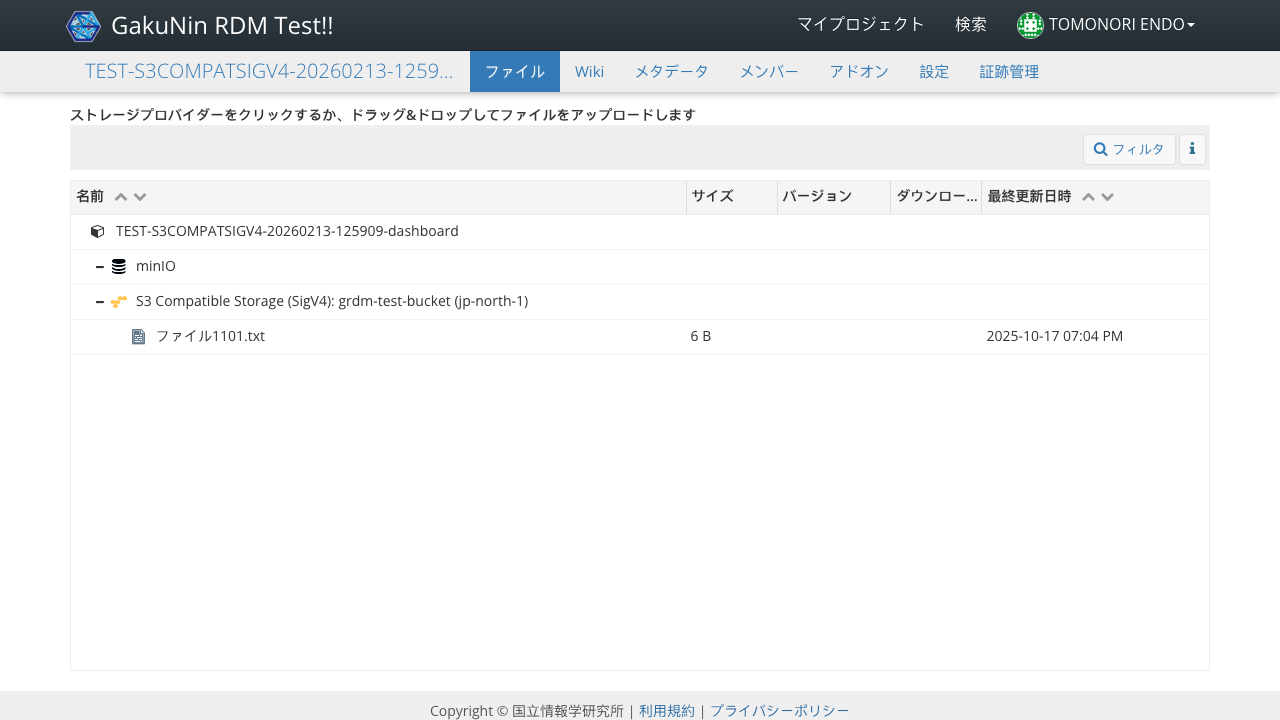

In [28]:
import traceback

async def _step(page):
    try:
        await page.get_by_role("link", name="ファイルページ").click()
    except:
        # GitHub Actions環境では、前のセルで「正常にリンクされました」が出ても、この段階でファイルページリンクが消えることがある
        # そのため、ファイルタブをクリックすることでフォールバックとする
        print('Ignored')
        traceback.print_exc()
        await page.locator('//*[@id = "projectNavFiles"]//a').click()


    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)


## プロジェクトダッシュボードでの「ファイル基本操作」テストの実施

テスト「テスト手順-ストレージ共通-ファイル基本操作」をプロジェクトダッシュボードで実施する。

In [29]:
from datetime import datetime
import os
import papermill as pm
import traceback
from scripts.papermillHelpers import gen_run_notebook

def make_result_dir(base_path):
    result_dir = os.path.join(base_path, 'notebooks')
    os.makedirs(result_dir, exist_ok=True)
    return result_dir

result_dir = make_result_dir(default_result_path)

run_notebook = gen_run_notebook(
    result_dir,
    transition_timeout,
    dict(
        rdm_url=rdm_url,
        idp_name_1=idp_name_1,
        idp_username_1=idp_username_1,
        idp_password_1=idp_password_1,
    ),
    skip_failed_test,
    exclude_notebooks,
)

result_notebooks = []
result_dir


'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1/notebooks'

In [30]:
result_notebooks.append(run_notebook(
    'テスト手順-ストレージ共通-ファイル基本操作.ipynb',
    dict(
        enable_52gb_file_upload=False,
        target_storage_name=target_storage_name,
        target_storage_id=target_storage_id,
        target_file_view='project-dashboard',
        rdm_project_name=f'{rdm_project_prefix}-dashboard',
        enable_1gb_file_upload=enable_1gb_file_upload,
        skip_preview_check=skip_preview_check,
        skip_130mb_upload=skip_130mb_upload,
    ),
    f'-ファイル基本操作-プロジェクトダッシュボード-{target_storage_name}',
))
result_notebooks[-1]


Passed unknown parameter: enable_52gb_file_upload


Executing:   0%|          | 0/119 [00:00<?, ?cell/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


失敗しました。テストは続行します...


Traceback (most recent call last):
  File "/Users/endo.tomonori/Desktop/git/tishin-endou/RDM-e2e-test-nb/scripts/papermillHelpers.py", line 50, in run_notebook
    pm.execute_notebook(base_notebook, result_notebook, parameters=params)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 131, in execute_notebook
    raise_for_execution_errors(nb, output_path)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 251, in raise_for_execution_errors
    raise error
papermill.exceptions.PapermillExecutionError: 
---------------------------------------------------------------------------
Exception encountered at "In [12]":
---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
Cell In[12], line 32
     29     await expect(page.locator(f'//*[text() = "{filename}"]/../following-sibling::*//*[@role = "progressbar"]'

'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1/notebooks/テスト手順-ストレージ共通-ファイル基本操作-ファイル基本操作-プロジェクトダッシュボード-S3 Compatible Storage (SigV4).ipynb'

## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1770956460.280164 seconds


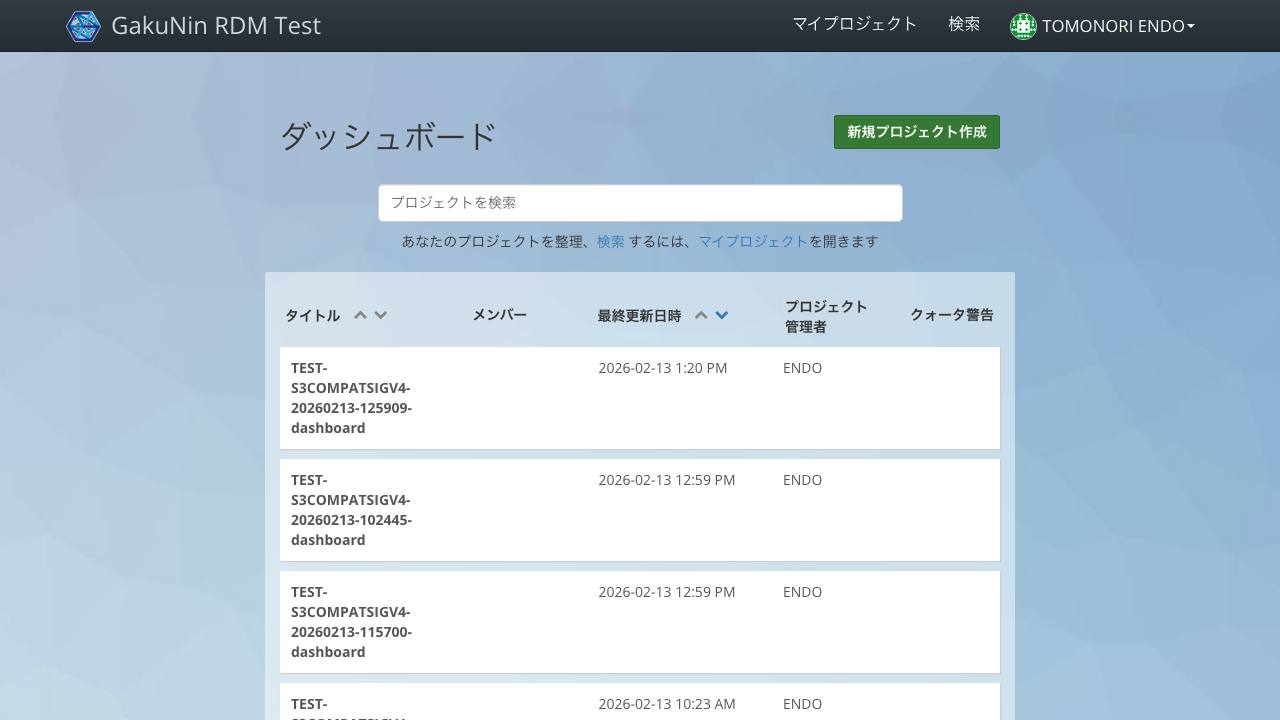

In [31]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TEST-対象ストレージ-YYYYMMDD-HHMMSS-filetab」プロジェクトを作成する

Start epoch: 1770956471.904809 seconds


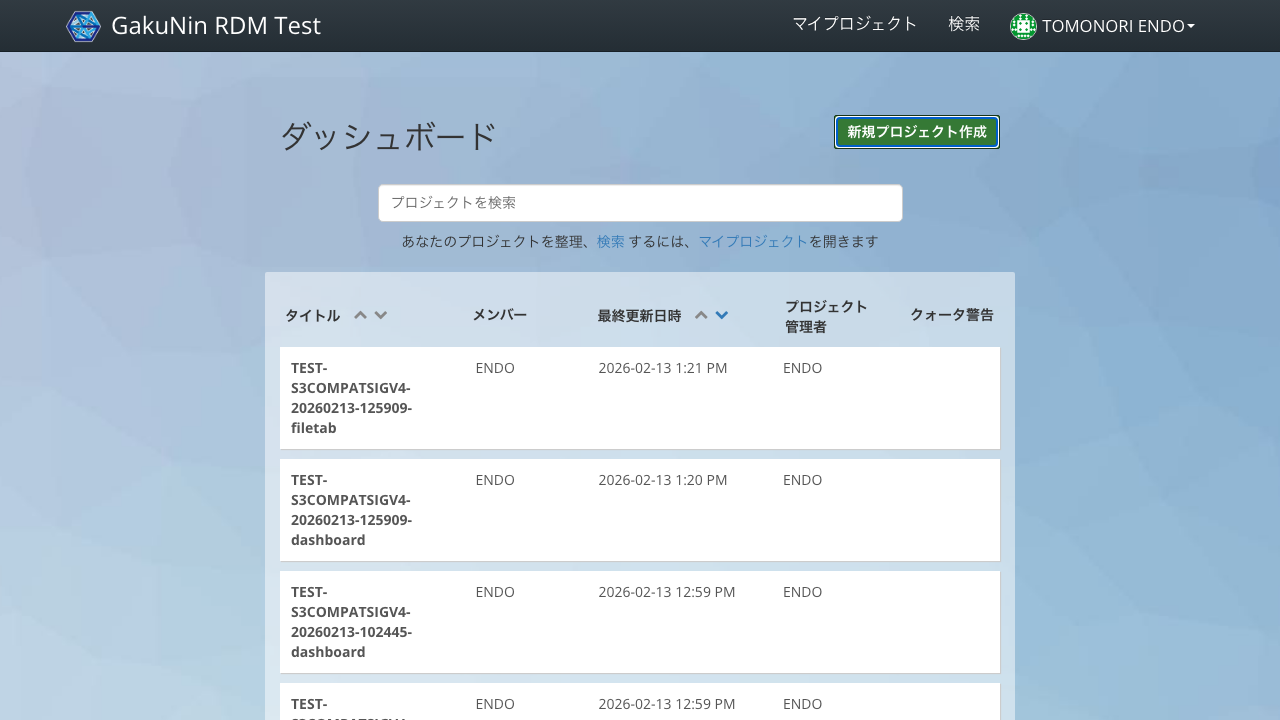

In [32]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-filetab', transition_timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

In [33]:
async def _step(page):
    await page.reload()
    project_item = page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-filetab"]')
    await expect(project_item).to_be_visible(timeout=transition_timeout)
    await project_item.click()

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1770956683.22664 seconds


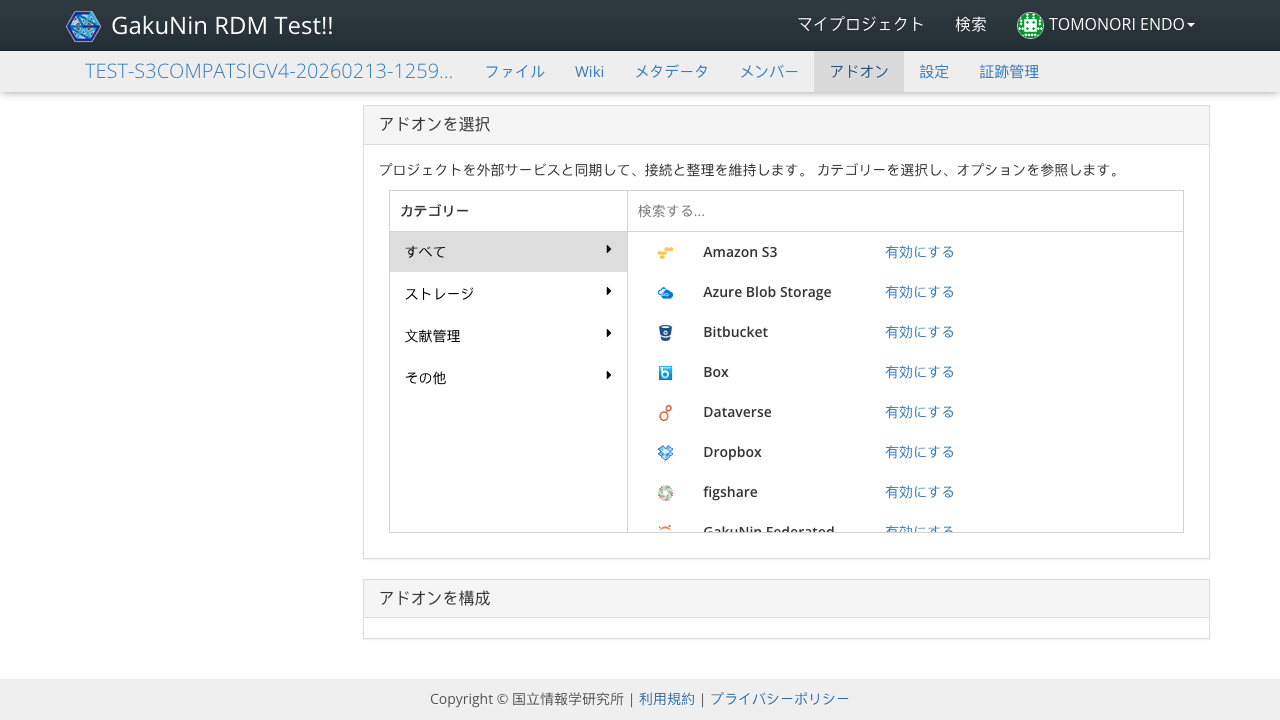

In [34]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1770956687.329419 seconds


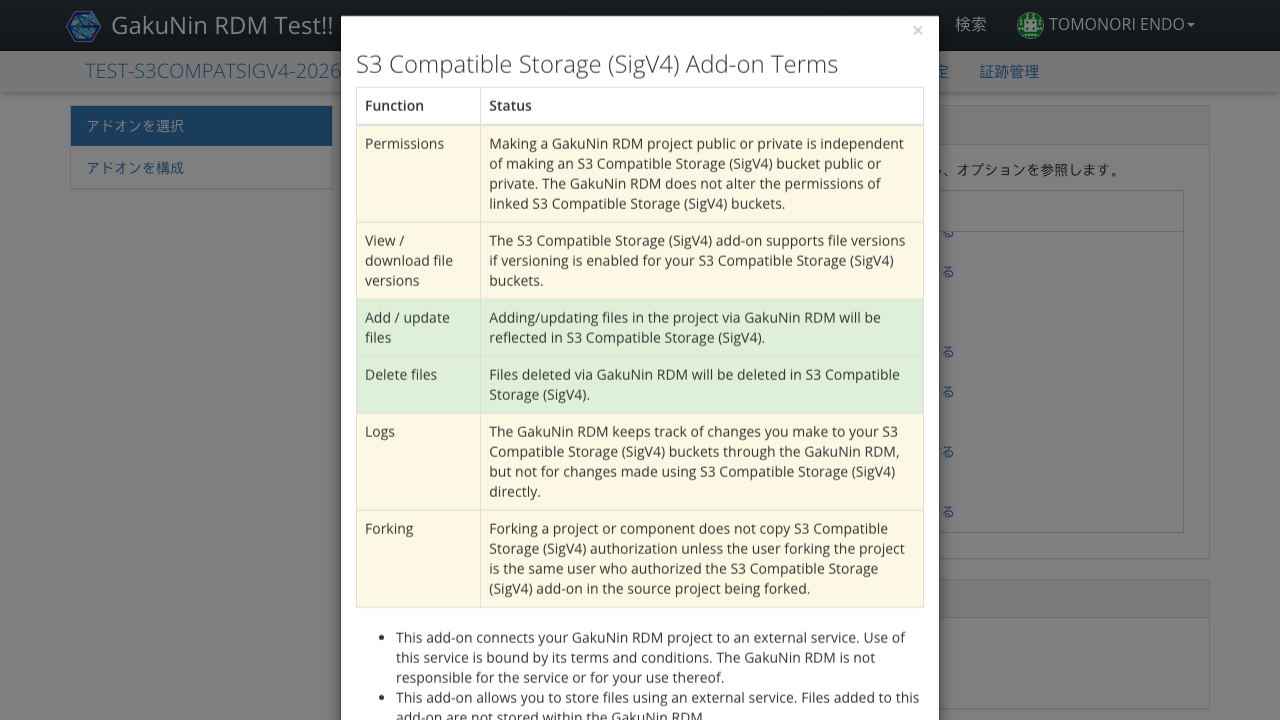

In [35]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()

    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「確認」をクリックする

Start epoch: 1770956688.8246322 seconds


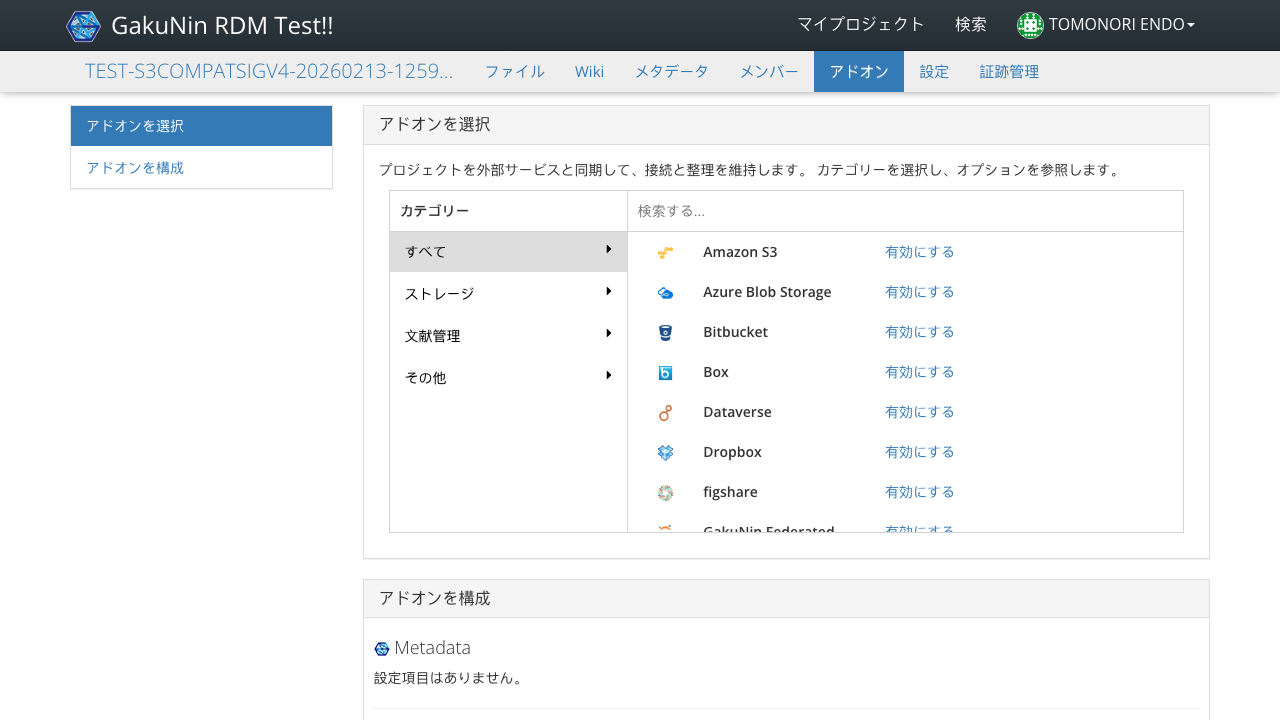

In [36]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()

    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「プロフィールからアカウントをインポート」リンクをクリックする

Start epoch: 1770956691.706283 seconds


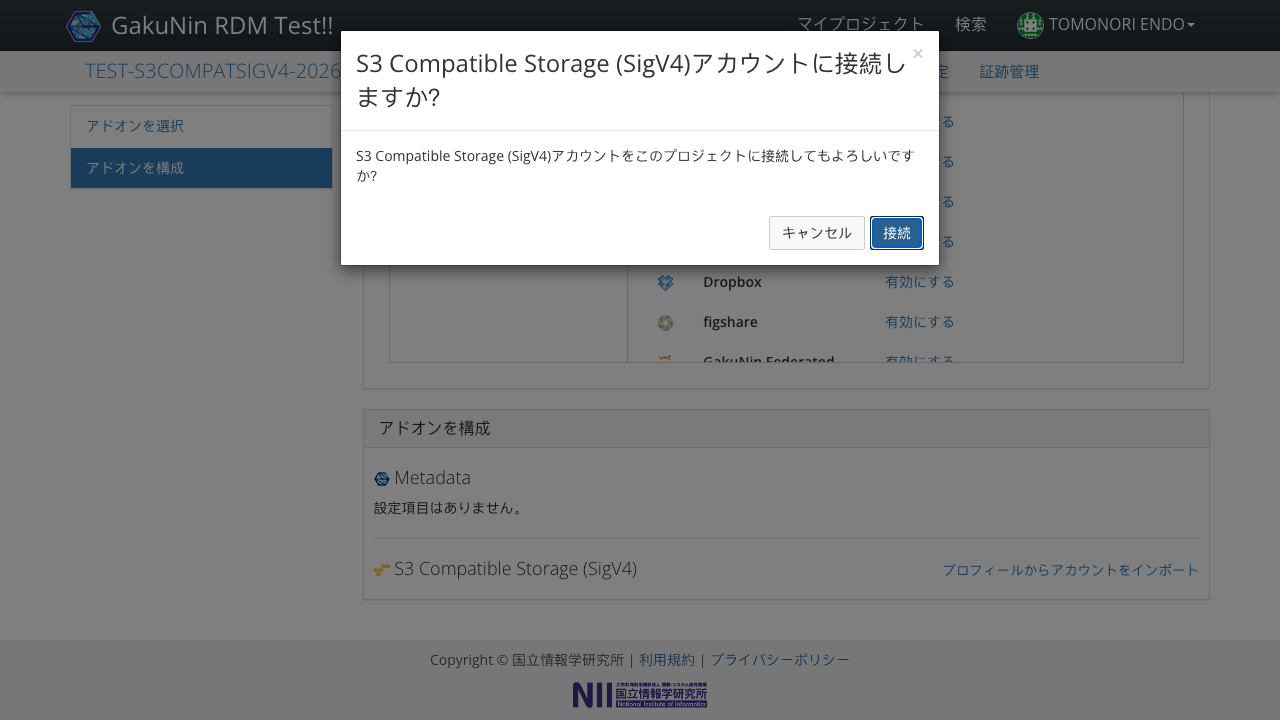

In [37]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「接続」をクリックする

Start epoch: 1770956695.84743 seconds


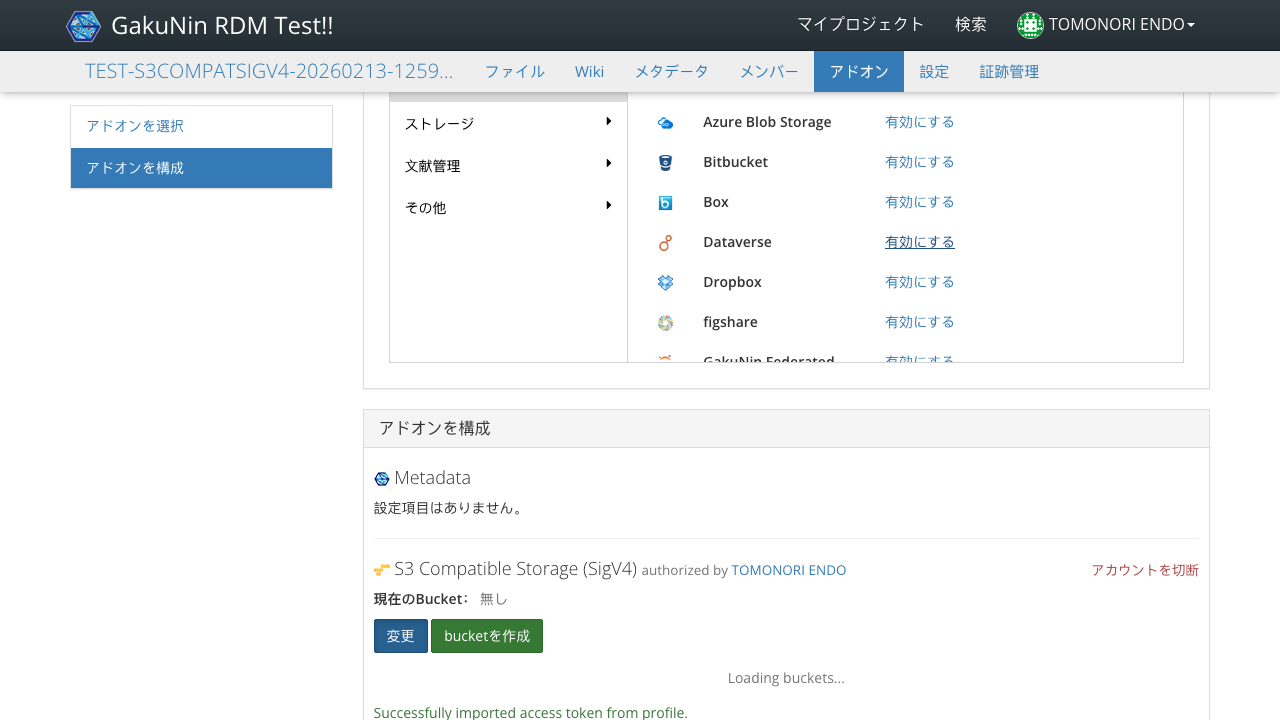

In [38]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//button[@id = "newBucket"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 指定されたバケットを選択する

Start epoch: 1770956706.404949 seconds


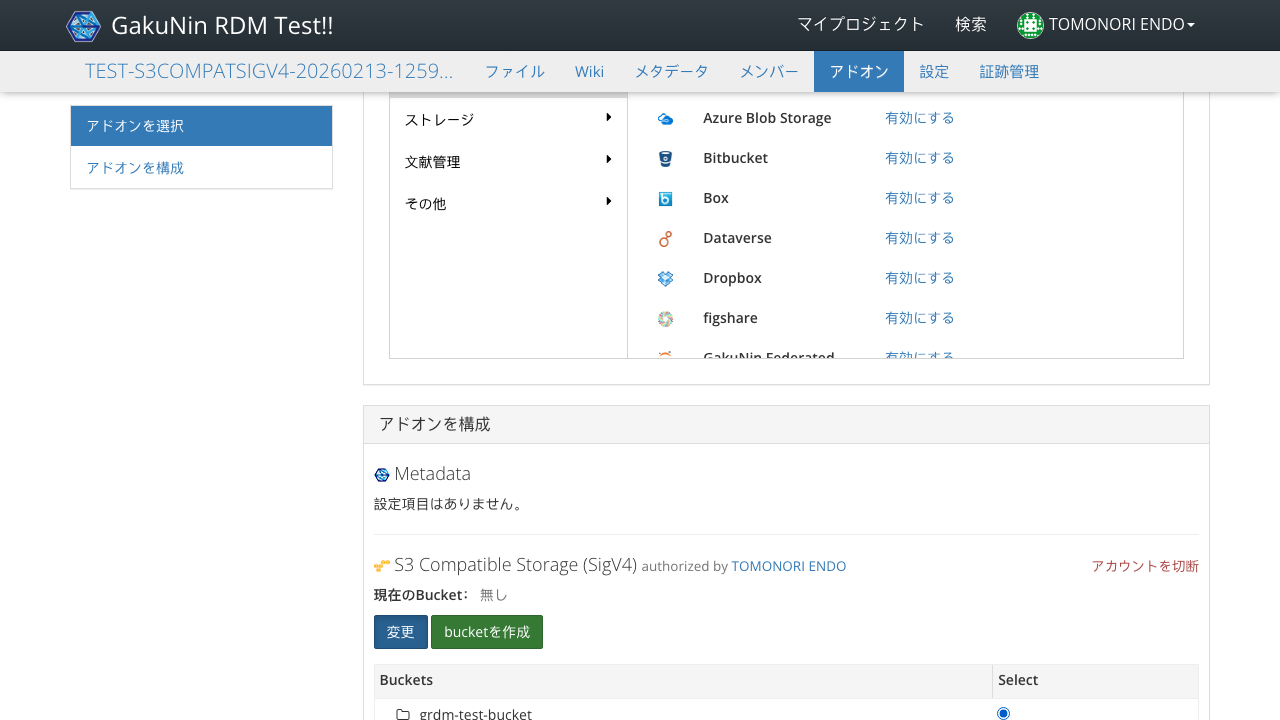

In [39]:
async def _step(page):
    await page.locator(f'//span[text() = "{s3_test_bucket_name_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770956708.177563 seconds


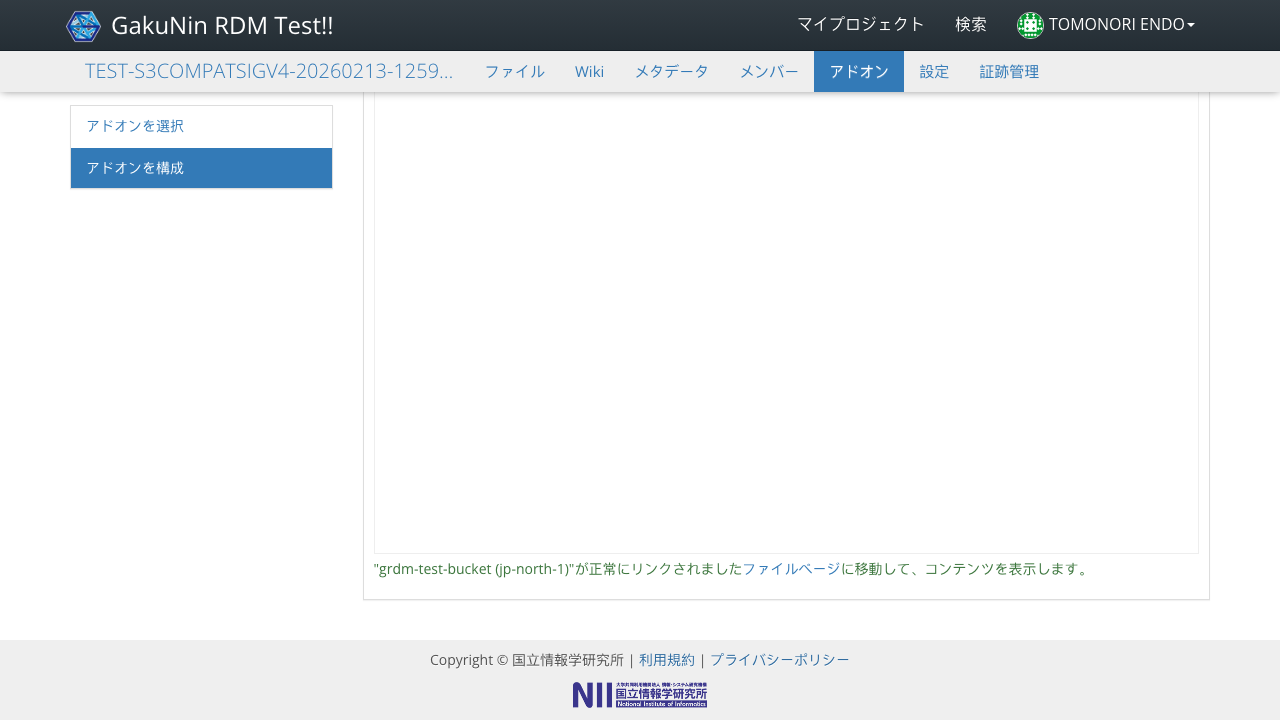

In [40]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(1)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)


## 「ファイルページ」リンクをクリックする

Start epoch: 1770956716.125551 seconds


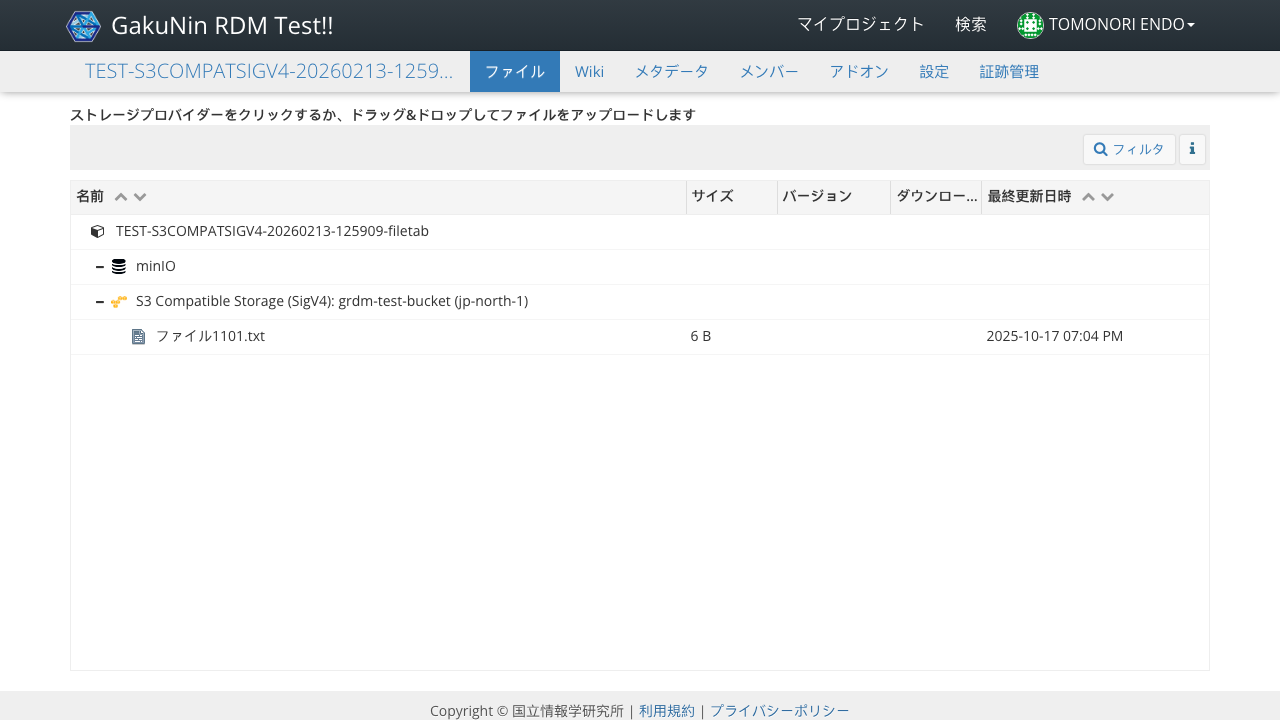

In [41]:
import traceback

async def _step(page):
    try:
        await page.get_by_role("link", name="ファイルページ").click()
    except:
        # GitHub Actions環境では、前のセルで「正常にリンクされました」が出ても、この段階でファイルページリンクが消えることがある
        # そのため、ファイルタブをクリックすることでフォールバックとする
        print('Ignored')
        traceback.print_exc()
        await page.locator('//*[@id = "projectNavFiles"]//a').click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)


## ファイルタブでの「ファイル基本操作」テストの実施

テスト「テスト手順-ストレージ共通-ファイル基本操作」をファイルタブで実施する。

In [42]:
result_notebooks.append(run_notebook(
    'テスト手順-ストレージ共通-ファイル基本操作.ipynb',
    dict(
        enable_52gb_file_upload=False,
        target_storage_name=target_storage_name,
        target_storage_id=target_storage_id,
        target_file_view='file-tab',
        rdm_project_name=f'{rdm_project_prefix}-filetab',
        enable_1gb_file_upload=enable_1gb_file_upload,
        skip_preview_check=skip_preview_check,
        skip_130mb_upload=skip_130mb_upload,
    ),
    f'-ファイル基本操作-ファイルタブ-{target_storage_name}',
))
result_notebooks[-1]


Passed unknown parameter: enable_52gb_file_upload


Executing:   0%|          | 0/119 [00:00<?, ?cell/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


失敗しました。テストは続行します...


Traceback (most recent call last):
  File "/Users/endo.tomonori/Desktop/git/tishin-endou/RDM-e2e-test-nb/scripts/papermillHelpers.py", line 50, in run_notebook
    pm.execute_notebook(base_notebook, result_notebook, parameters=params)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 131, in execute_notebook
    raise_for_execution_errors(nb, output_path)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 251, in raise_for_execution_errors
    raise error
papermill.exceptions.PapermillExecutionError: 
---------------------------------------------------------------------------
Exception encountered at "In [12]":
---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
Cell In[12], line 32
     29     await expect(page.locator(f'//*[text() = "{filename}"]/../following-sibling::*//*[@role = "progressbar"]'

'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1/notebooks/テスト手順-ストレージ共通-ファイル基本操作-ファイル基本操作-ファイルタブ-S3 Compatible Storage (SigV4).ipynb'

## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1770956757.6367328 seconds


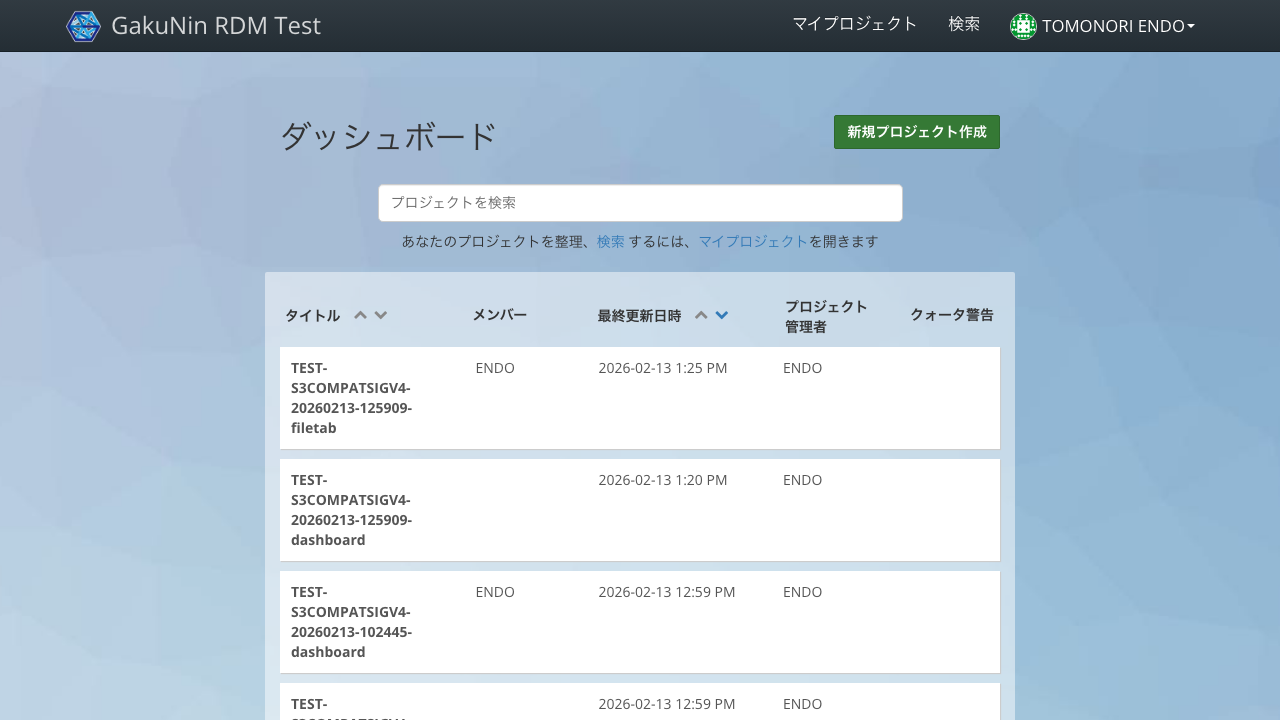

In [43]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TEST-対象ストレージ-YYYYMMDD-HHMMSS-metadata」プロジェクトを作成する

Start epoch: 1770956765.526091 seconds


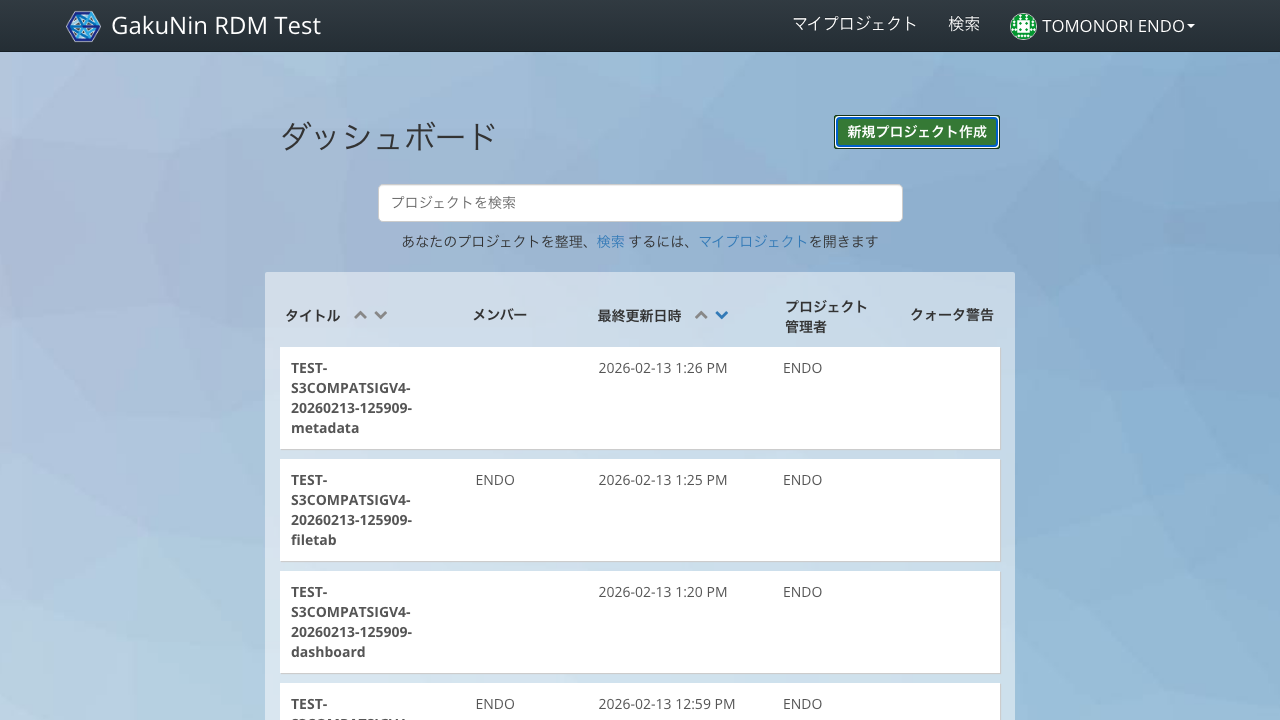

In [44]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-metadata', transition_timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

In [46]:
async def _step(page):
    await page.reload()
    project_item = page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-metadata"]')
    await expect(project_item).to_be_visible(timeout=transition_timeout)
    await project_item.click()

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1770956836.14858 seconds


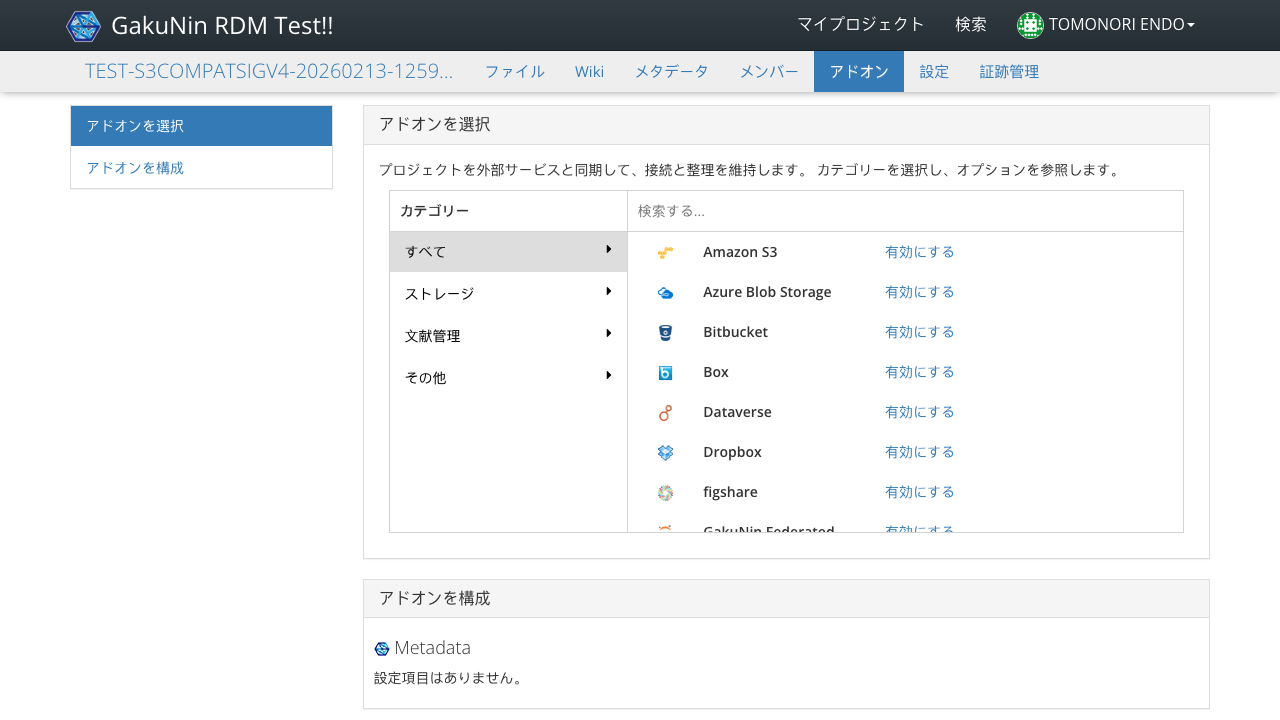

In [47]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1770956839.893302 seconds


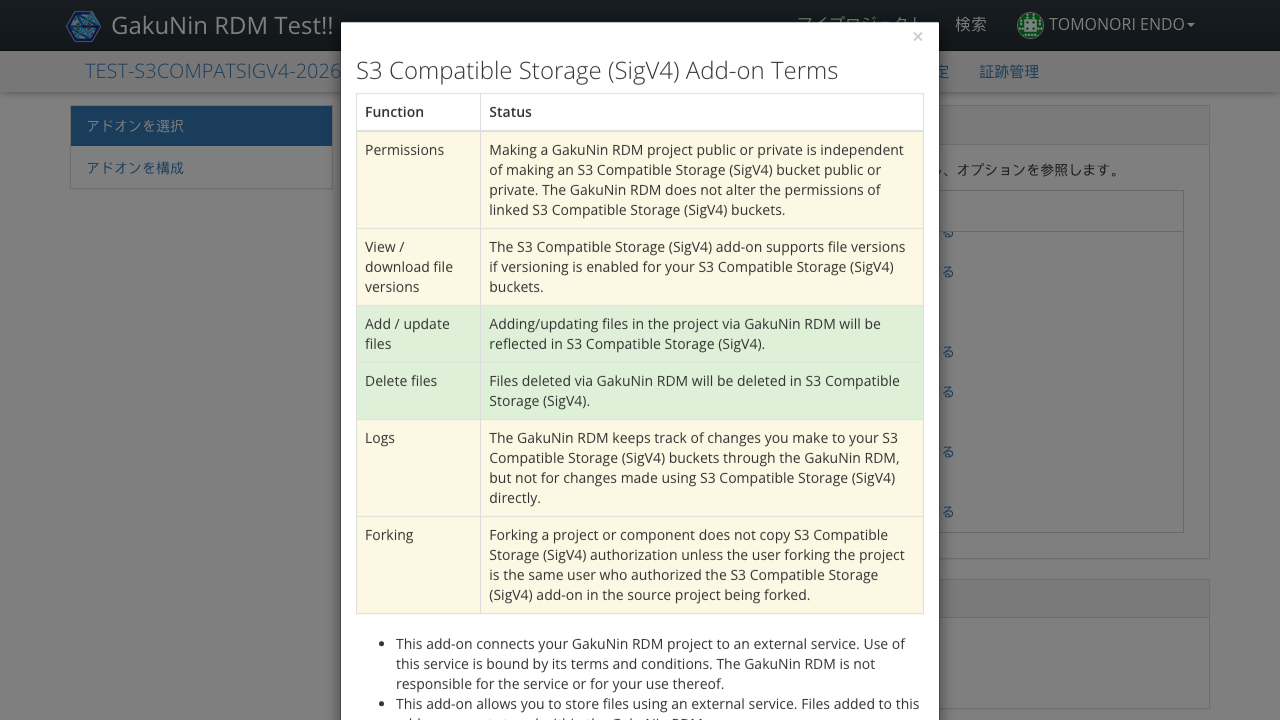

In [48]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()

    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「確認」をクリックする

Start epoch: 1770956841.670988 seconds


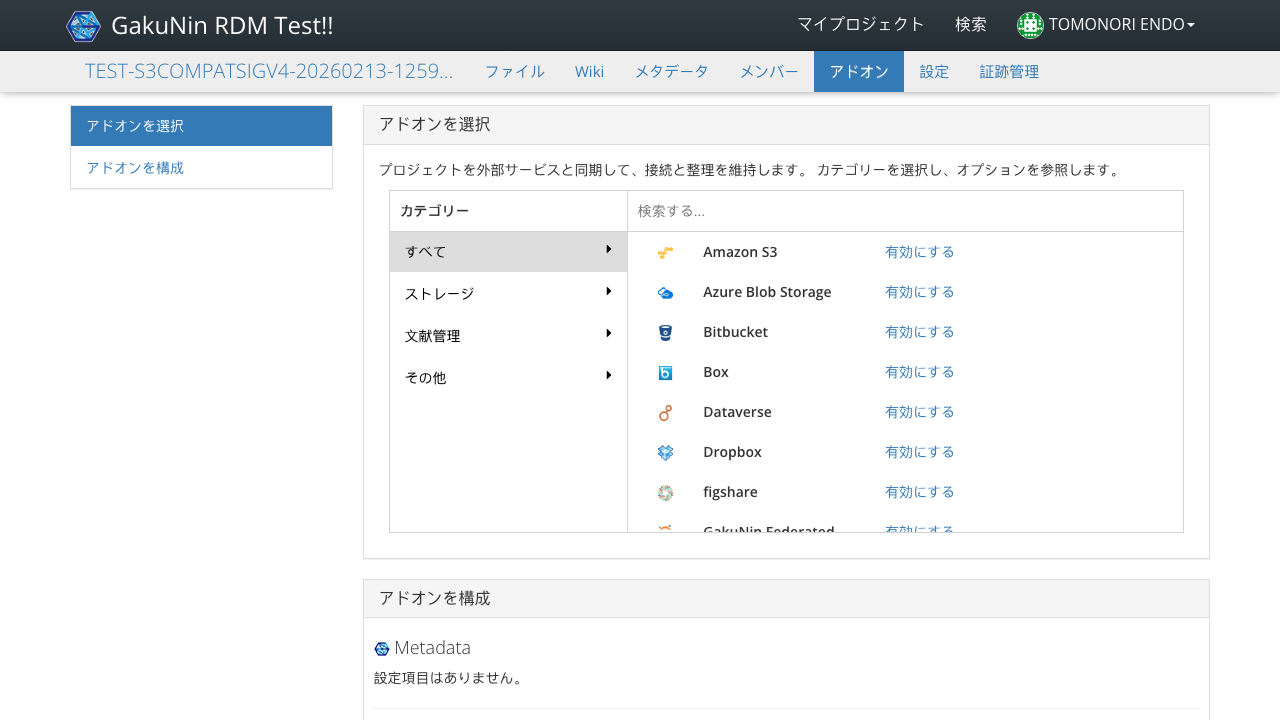

In [49]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()

    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「プロフィールからアカウントをインポート」リンクをクリックする

Start epoch: 1770956846.3669918 seconds


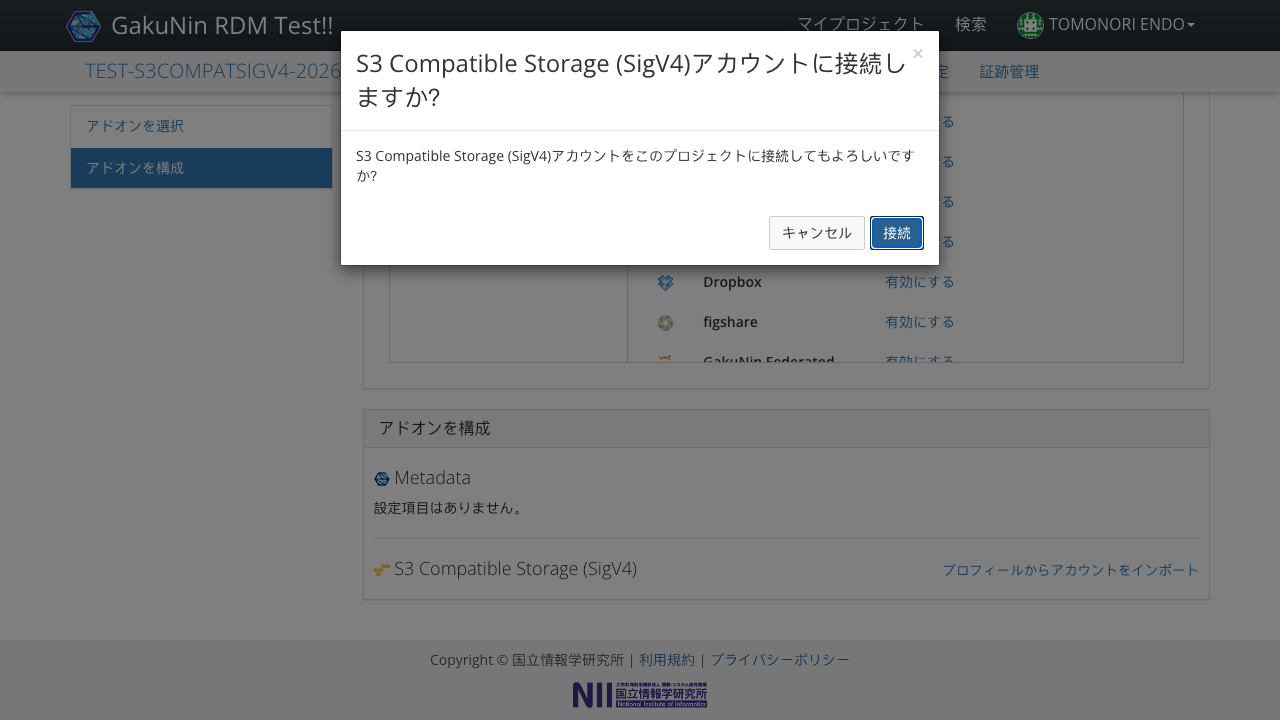

In [50]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「接続」をクリックする

Start epoch: 1770956849.385304 seconds


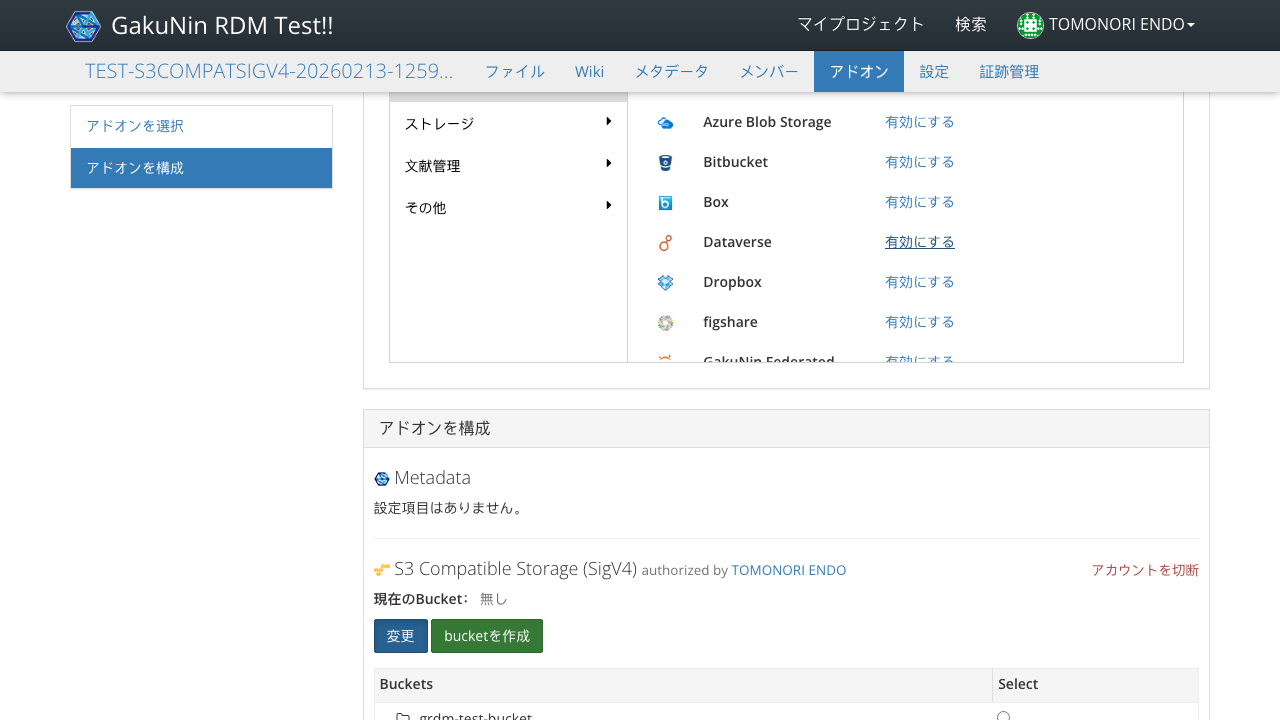

In [51]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//button[@id = "newBucket"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 指定されたバケットを選択する

Start epoch: 1770956851.6930969 seconds


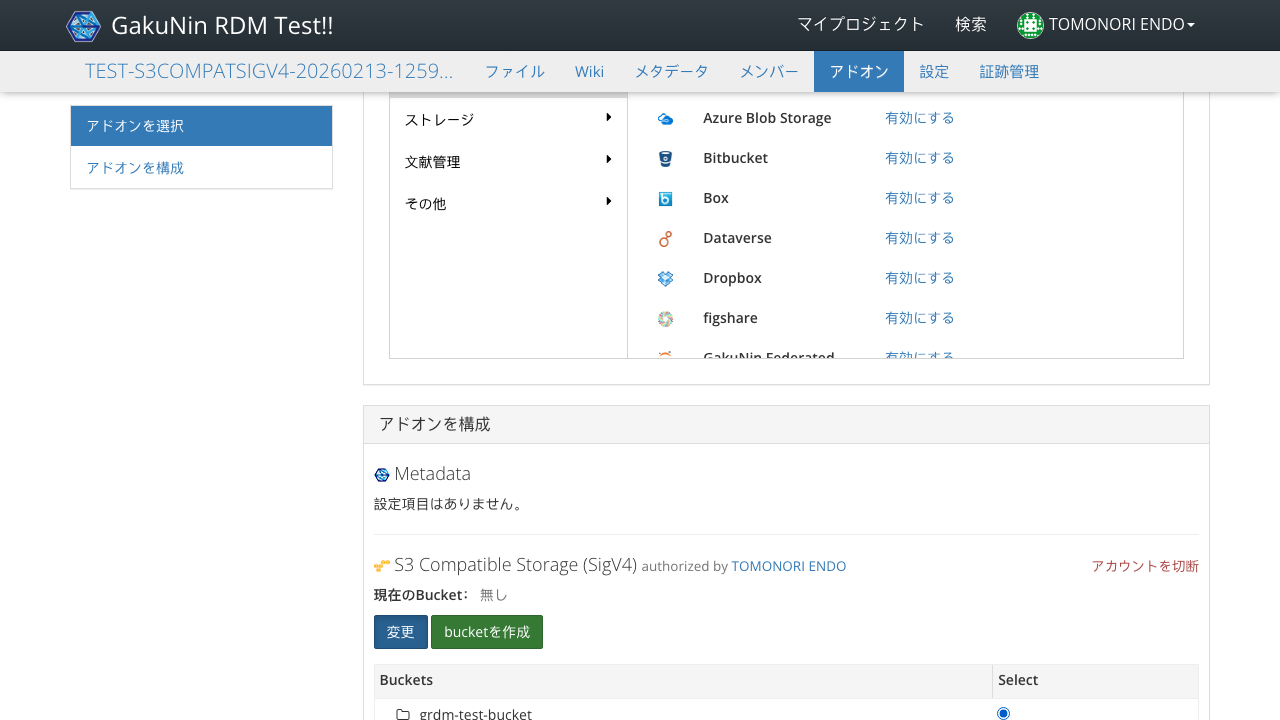

In [52]:
async def _step(page):
    await page.locator(f'//span[text() = "{s3_test_bucket_name_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770956853.1630661 seconds


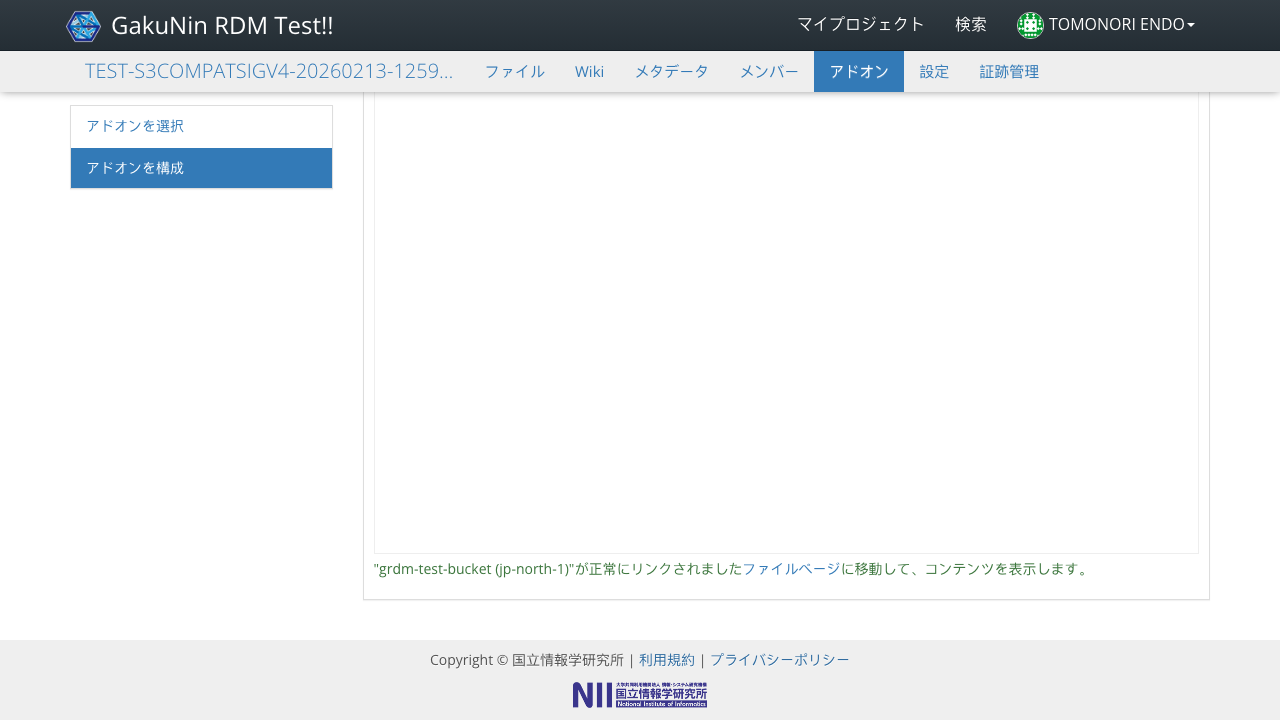

In [53]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(1)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)


## 「ファイルページ」リンクをクリックする

Start epoch: 1770956856.4082 seconds


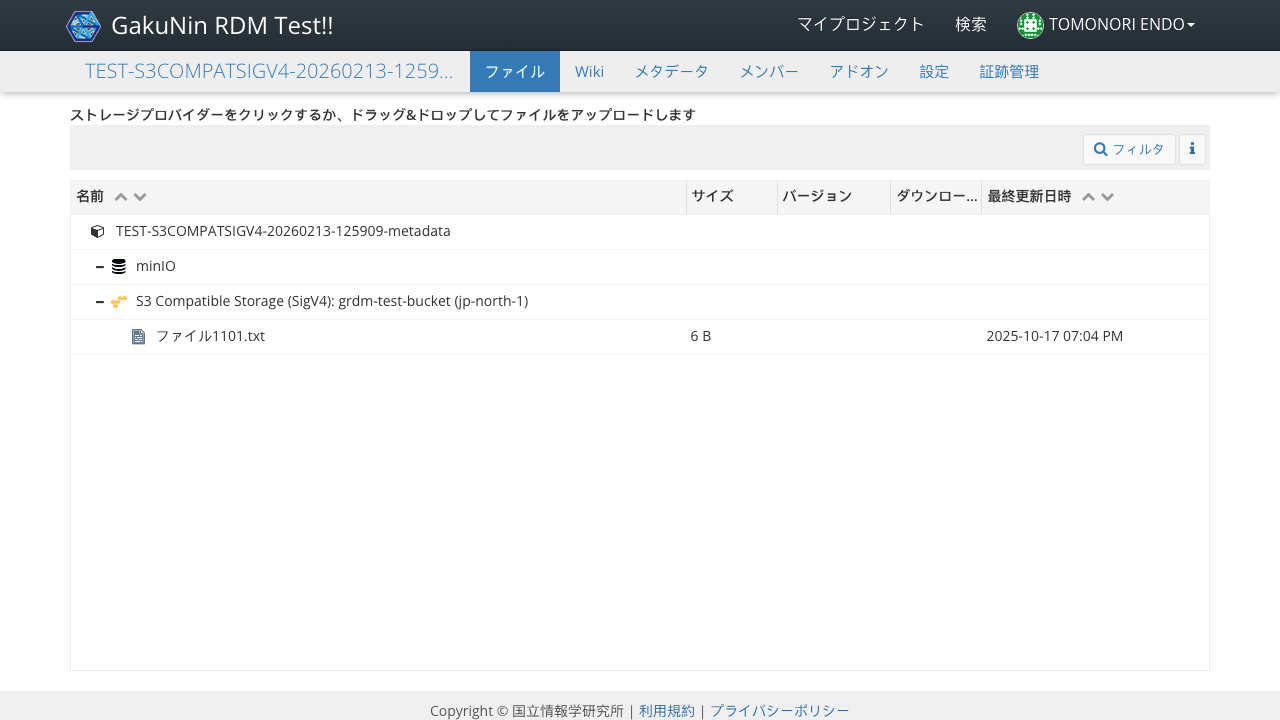

In [54]:
import traceback

async def _step(page):
    try:
        await page.get_by_role("link", name="ファイルページ").click()
    except:
        print('Ignored')
        traceback.print_exc()
        await page.locator('//*[@id = "projectNavFiles"]//a').click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)


## ストレージでの「Metadataアドオンの登録」テストの実施

テスト「テスト手順-ストレージ共通-Metadataアドオン」をファイルタブで実施する。

In [55]:
result_notebooks.append(run_notebook(
    'テスト手順-ストレージ共通-Metadataアドオン.ipynb',
    dict(
        target_storage_name=target_storage_name,
        target_storage_id=target_storage_id,
        rdm_project_name=f'{rdm_project_prefix}-metadata'
    ),
    f'Metadataアドオン-{target_storage_name}',
))
result_notebooks[-1]


## ユーザーメニューから「設定」を選択する

Start epoch: 1770956934.9953191 seconds


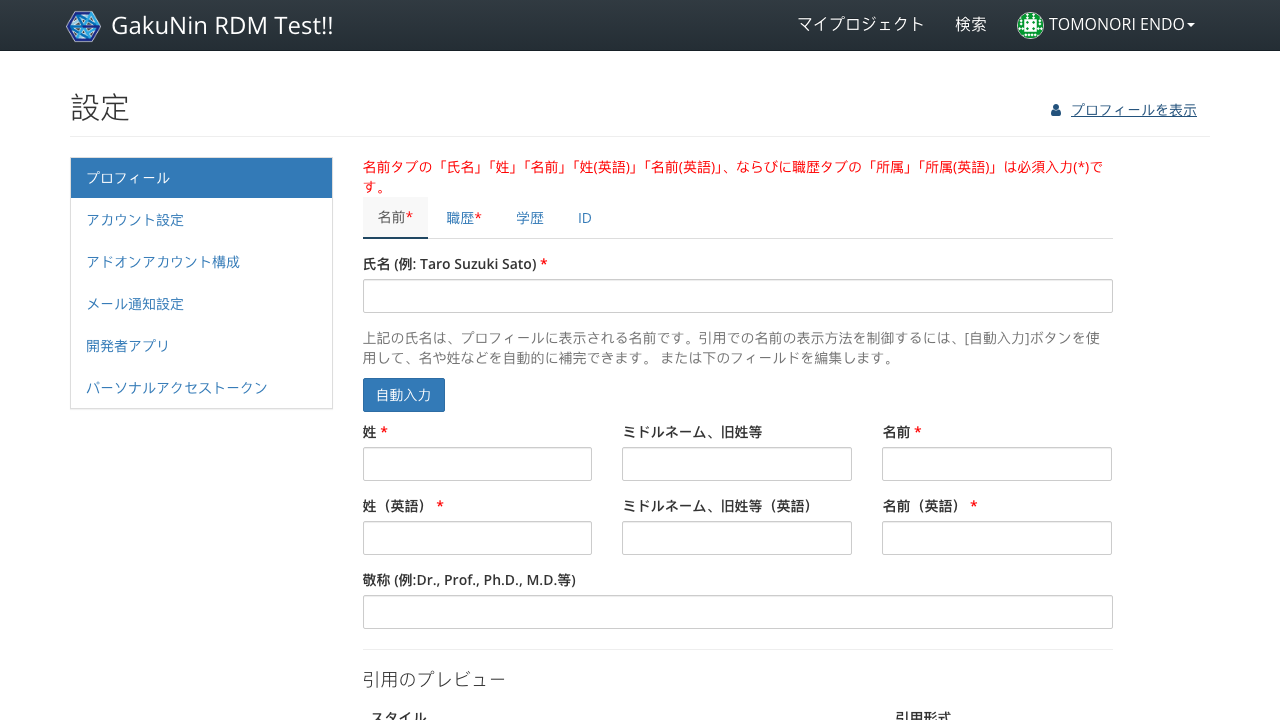

In [57]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@href="/settings/"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンアカウント構成」を選択する

Start epoch: 1770956937.7705019 seconds


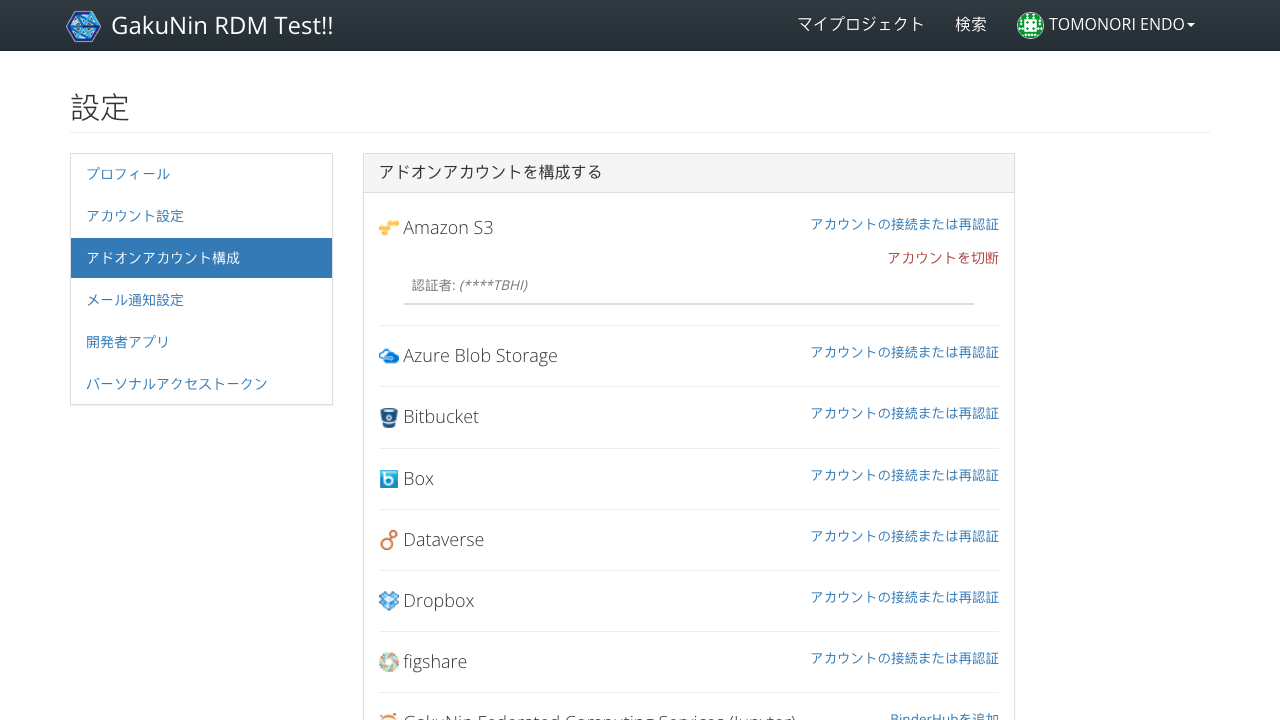

In [58]:
import traceback

async def _step(page):
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[@data-bind="text: properName" and text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 対象ストレージの「アカウントの接続または再認証」をクリックする

Start epoch: 1770956941.3807302 seconds


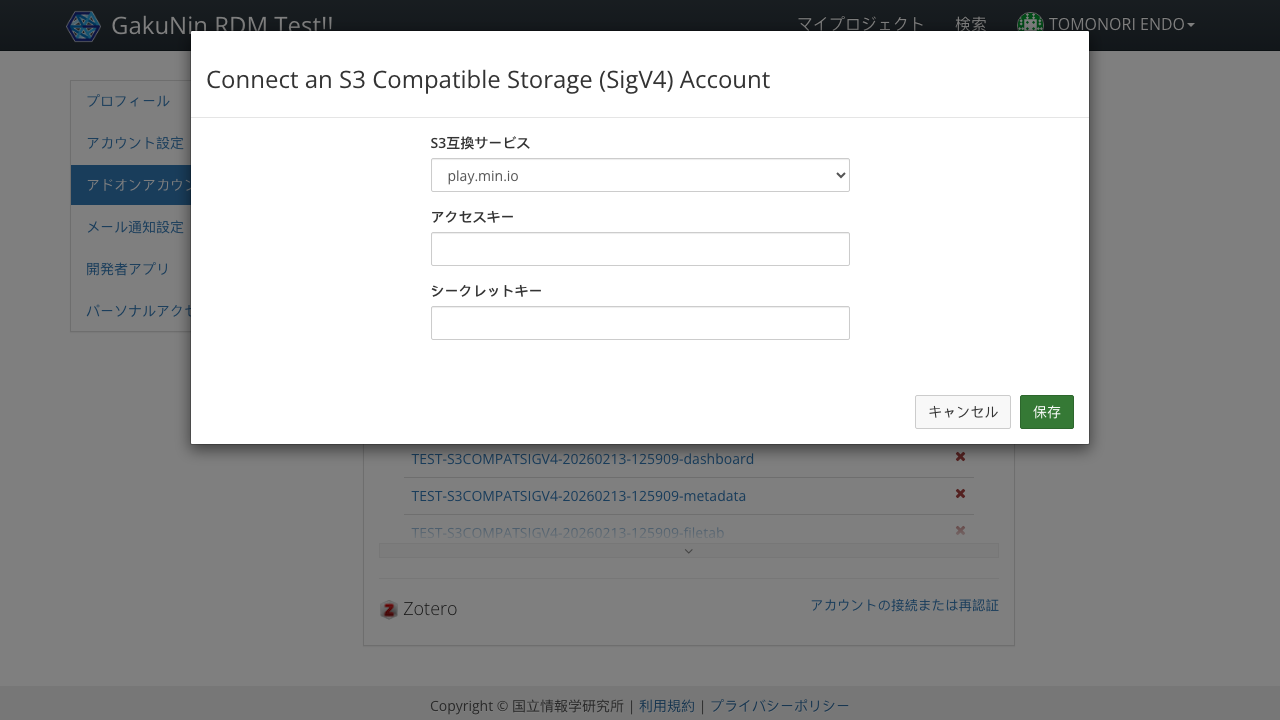

In [59]:
async def _step(page):
    await page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/..//*[text() = "アカウントの接続または再認証"]').click()

    await expect(page.locator(f'#{target_storage_id}InputCredentials .btn-success')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## S3互換サービスを選択し、アクセスキーとシークレットキー(2つ目)を入力する

In [ ]:
async def _step(page):
    # S3 Compatible Service のドロップダウンからサービスを選択
    await page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//select[@id = "selected_service"]').select_option(s3compat_type_name_2)
    access_key_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "access_key"]')
    secret_access_key_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "secret_key"]')
    #endpoint_url_field = page.locator(f'//*[@id = "{target_storage_id}InputCredentials"]//input[@name = "endpoint_url"]')
    await access_key_field.fill(s3_access_key_2)
    await secret_access_key_field.fill(s3_secret_access_key_2)
    #await endpoint_url_field.fill(s3_endpoint_2)

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770956945.9298391 seconds


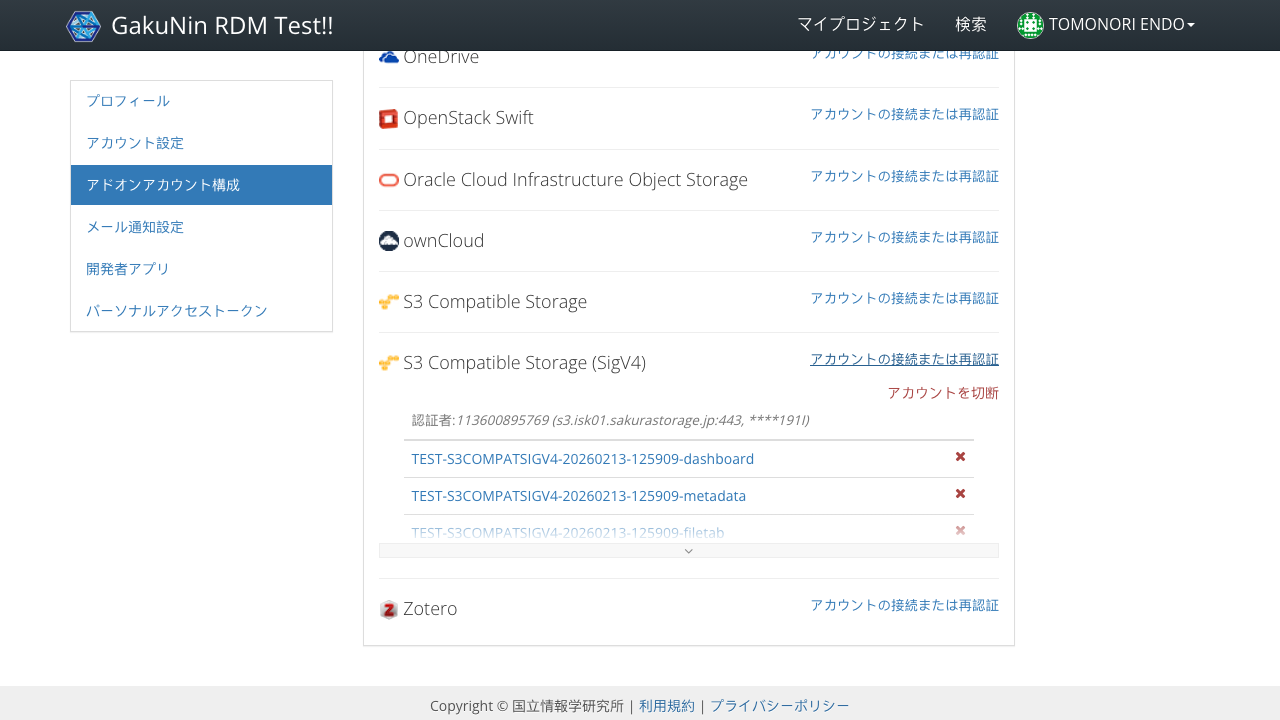

In [61]:
async def _step(page):
    await page.locator(f'#{target_storage_id}InputCredentials .btn-success').click()

    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(2, timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1770956959.679063 seconds


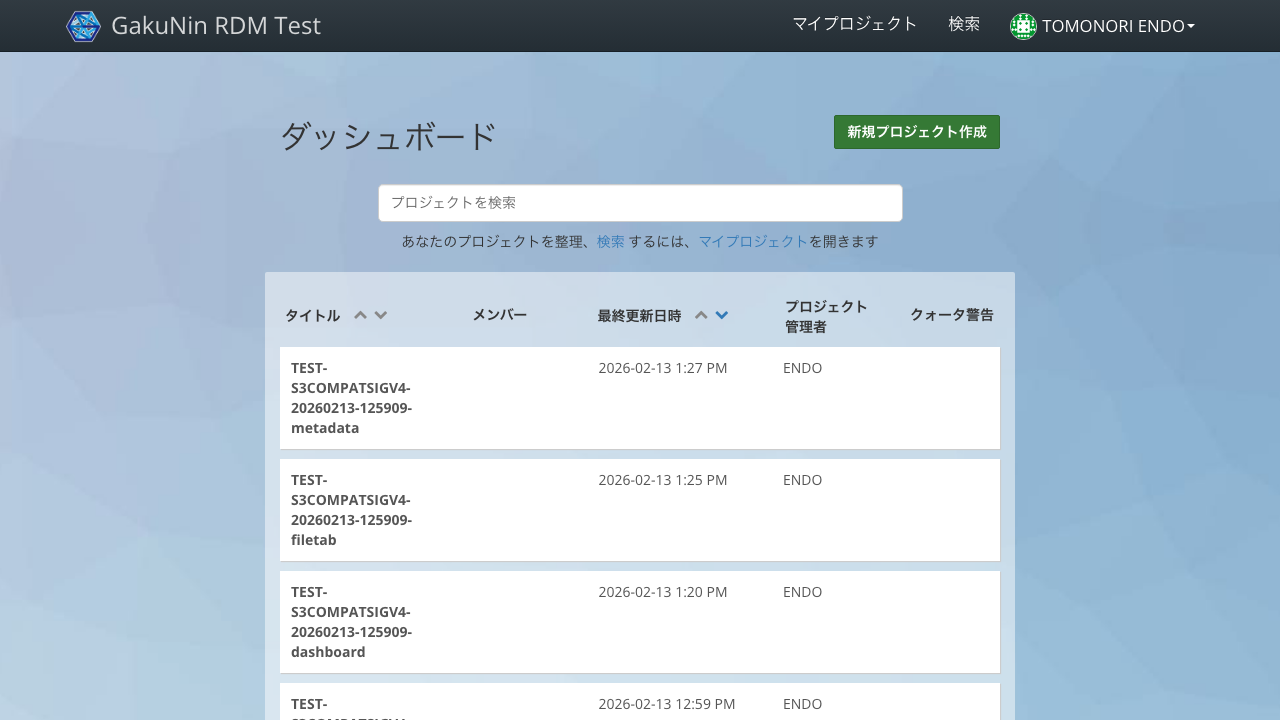

In [62]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TEST-対象ストレージ-YYYYMMDD-HHMMSS-toomany」プロジェクトを作成する

Start epoch: 1770956962.660306 seconds


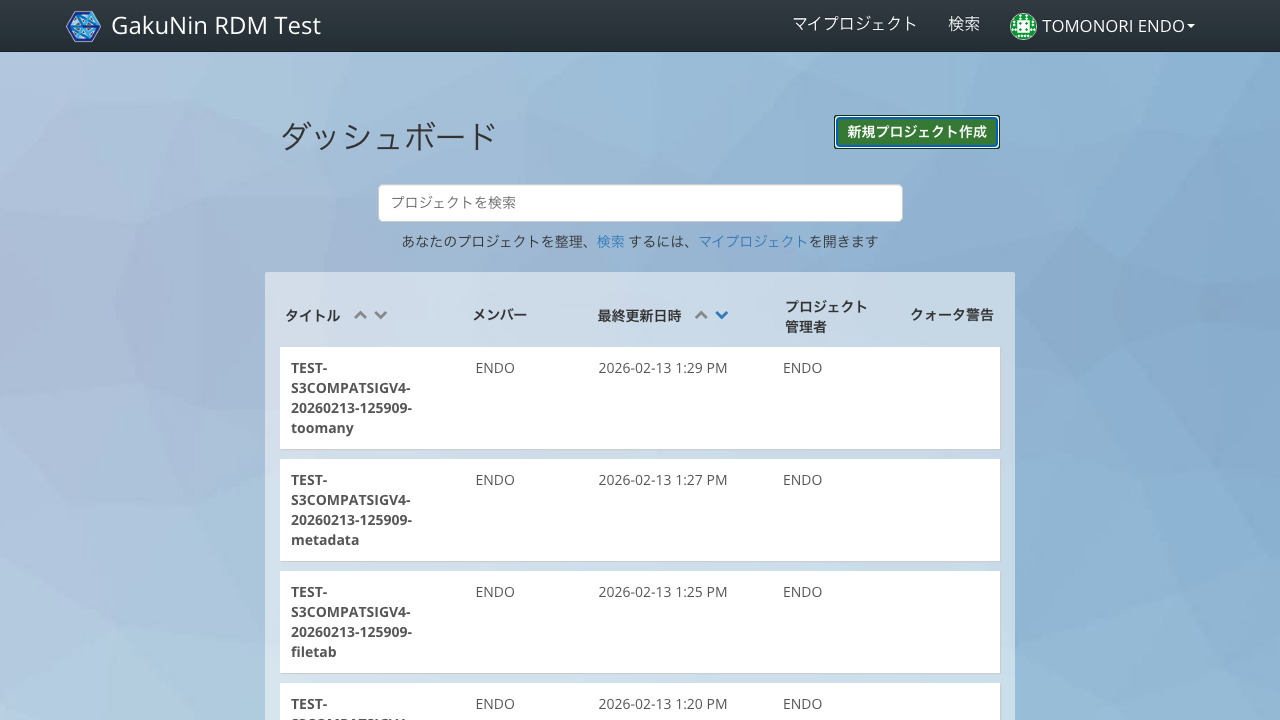

In [63]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-toomany', transition_timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

In [64]:
async def _step(page):
    await page.reload()
    project_item = page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-toomany"]')
    await expect(project_item).to_be_visible(timeout=transition_timeout)
    await project_item.click()

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1770956987.725333 seconds


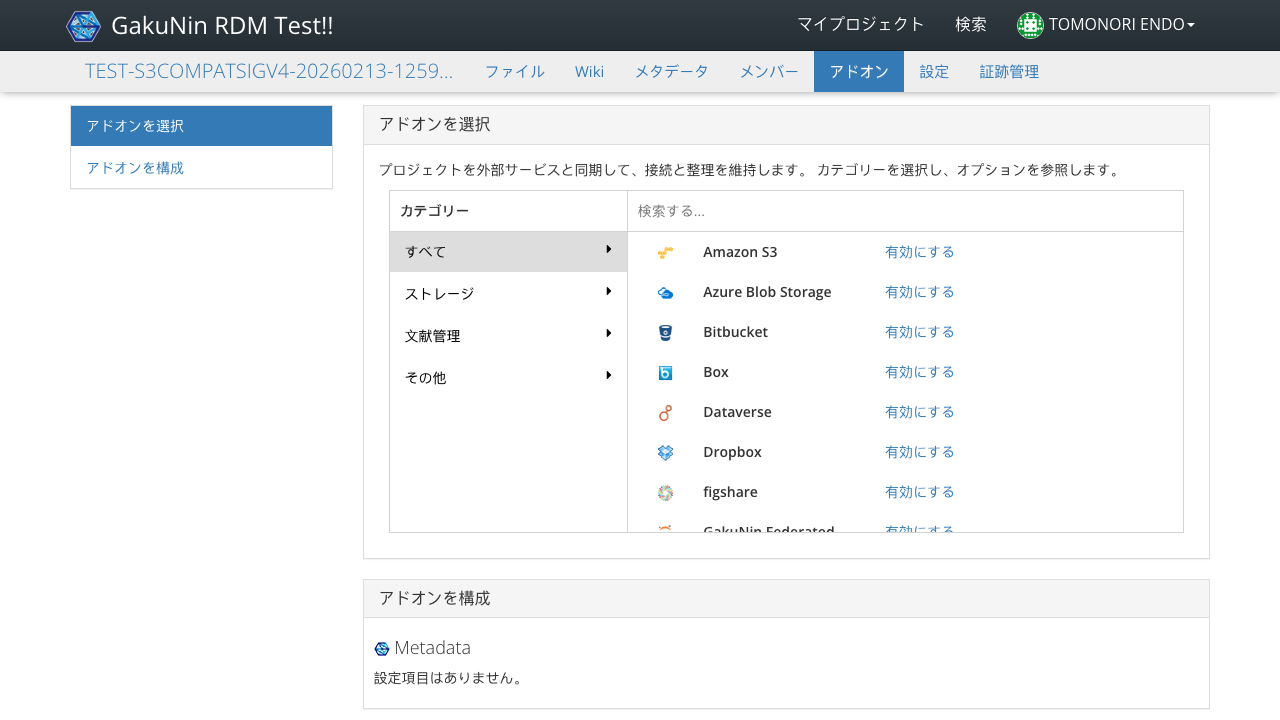

In [65]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1770956991.912118 seconds


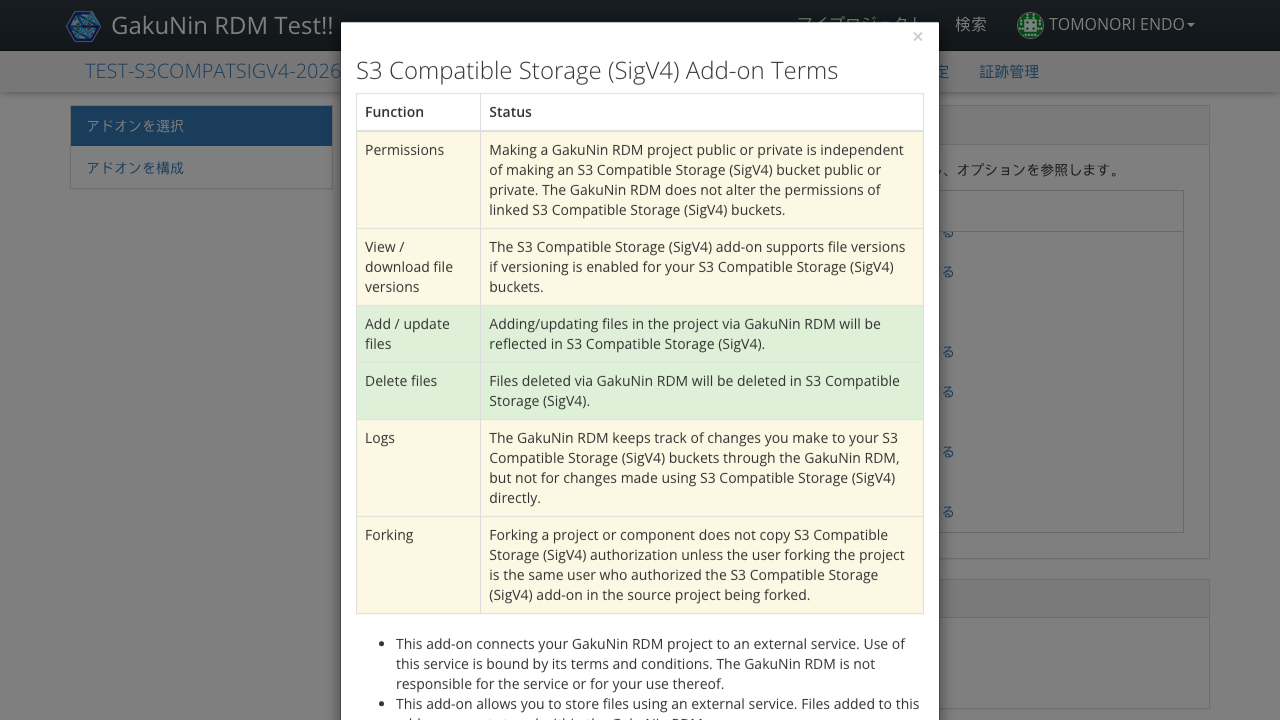

In [66]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()

    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「確認」をクリックする

Start epoch: 1770956994.3640351 seconds


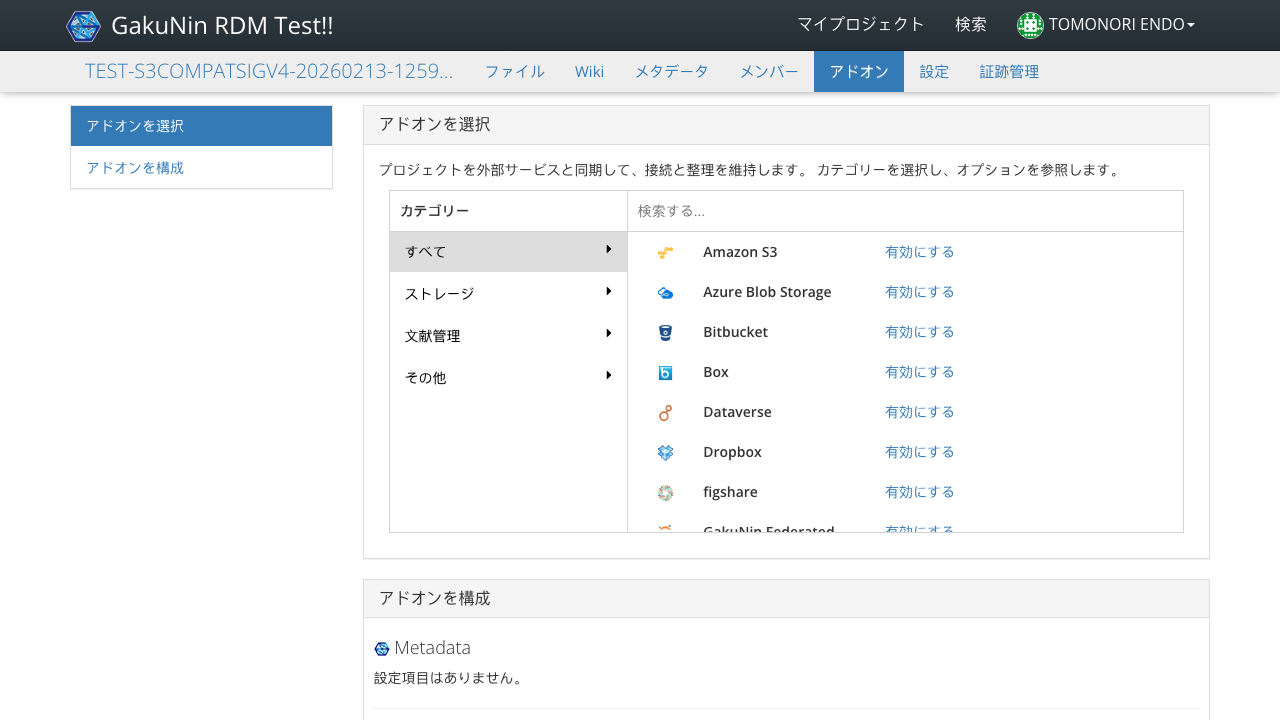

In [67]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()

    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「プロフィールからアカウントをインポート」リンクをクリックする

Start epoch: 1770956998.690918 seconds


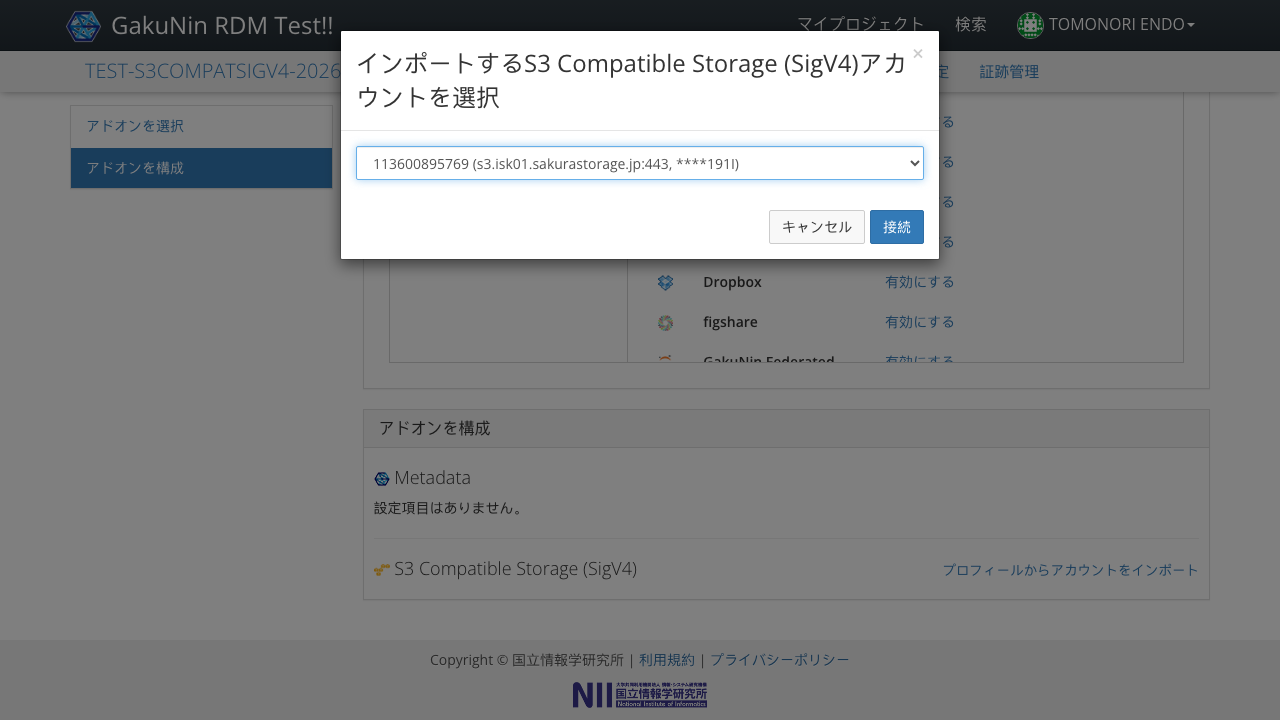

In [68]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## アカウントドロップダウンの2つ目を選択する

Start epoch: 1770957007.107744 seconds


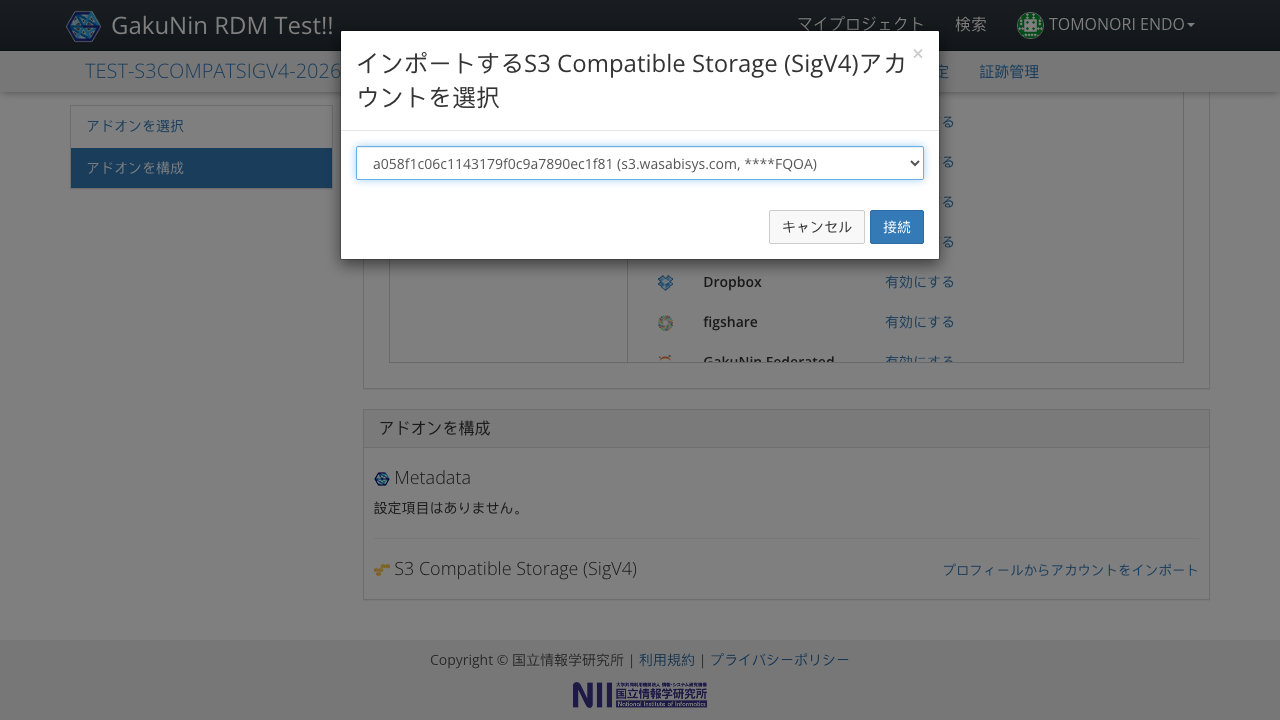

In [69]:
async def _step(page):
    await page.locator('//select[contains(@class, "bootbox-input-select")]').select_option(index=1)

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)


## 「接続」をクリックする

Start epoch: 1770957011.453978 seconds


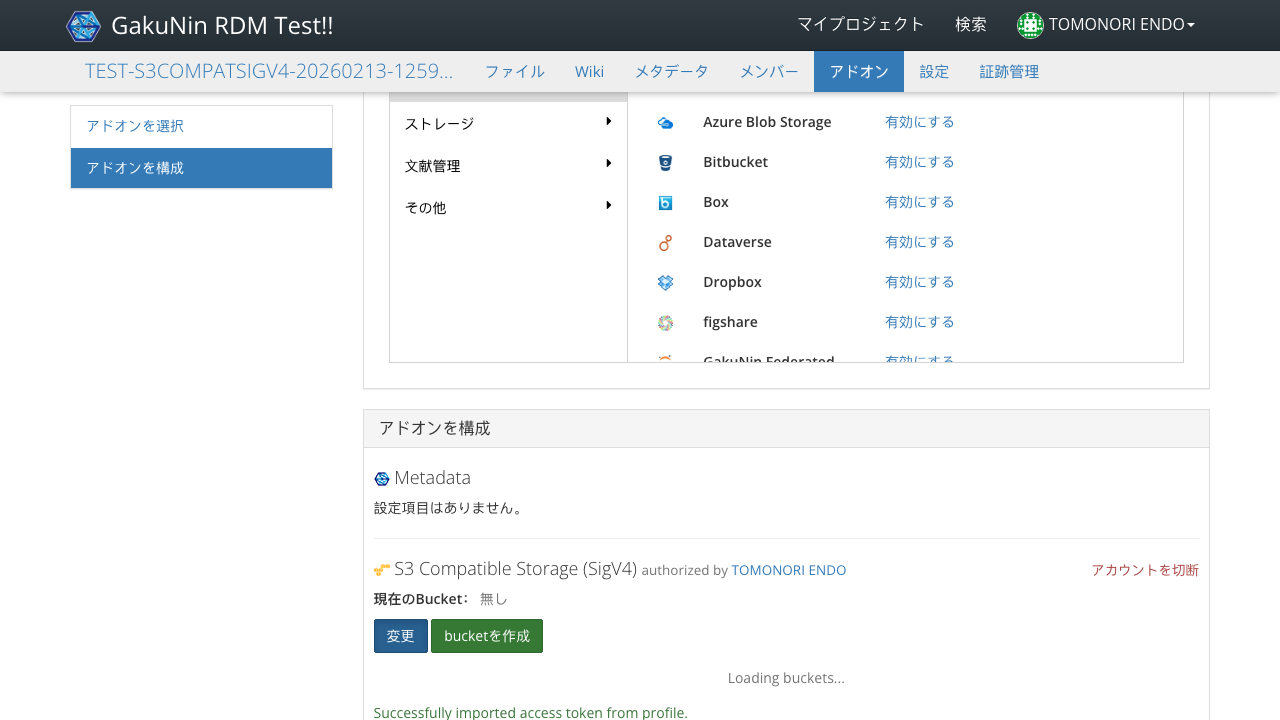

In [70]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//button[@id = "newBucket"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 指定されたバケットを選択する

Start epoch: 1770957016.5491571 seconds


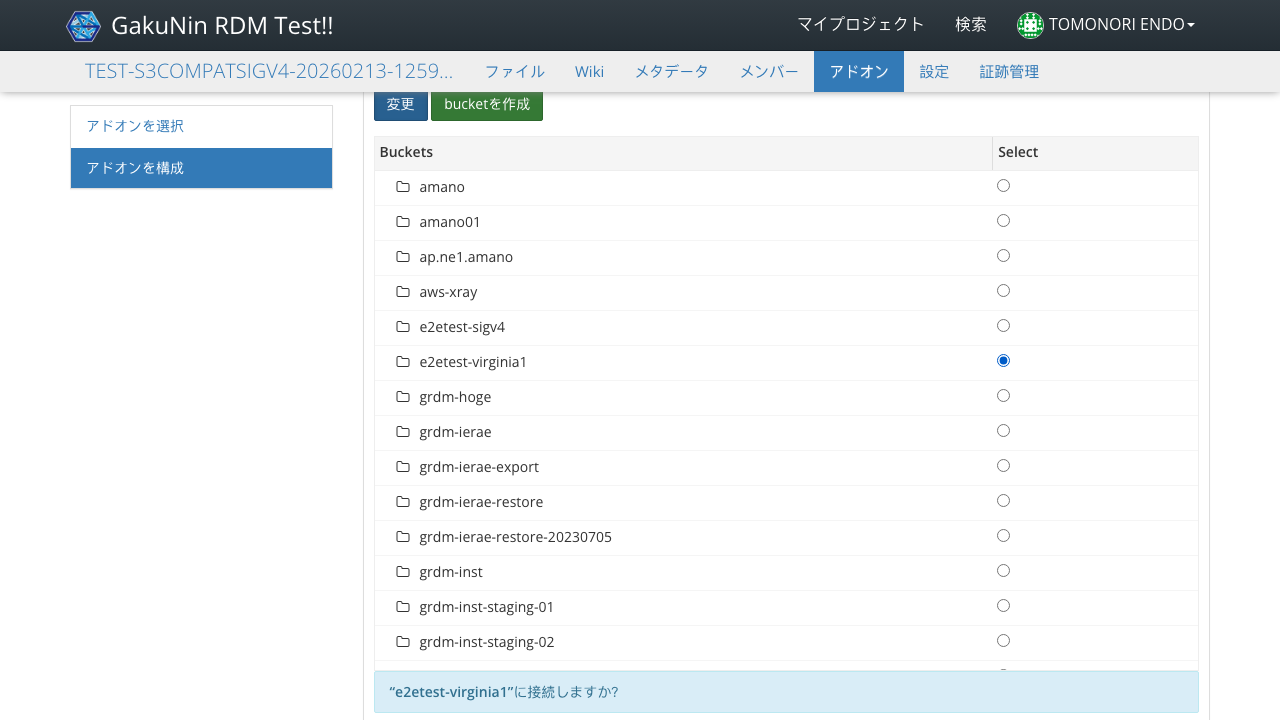

In [71]:
async def _step(page):
    await page.locator(f'//span[text() = "{s3_test_bucket_name_2}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)


## 「保存」をクリックする

Start epoch: 1770957054.5705988 seconds


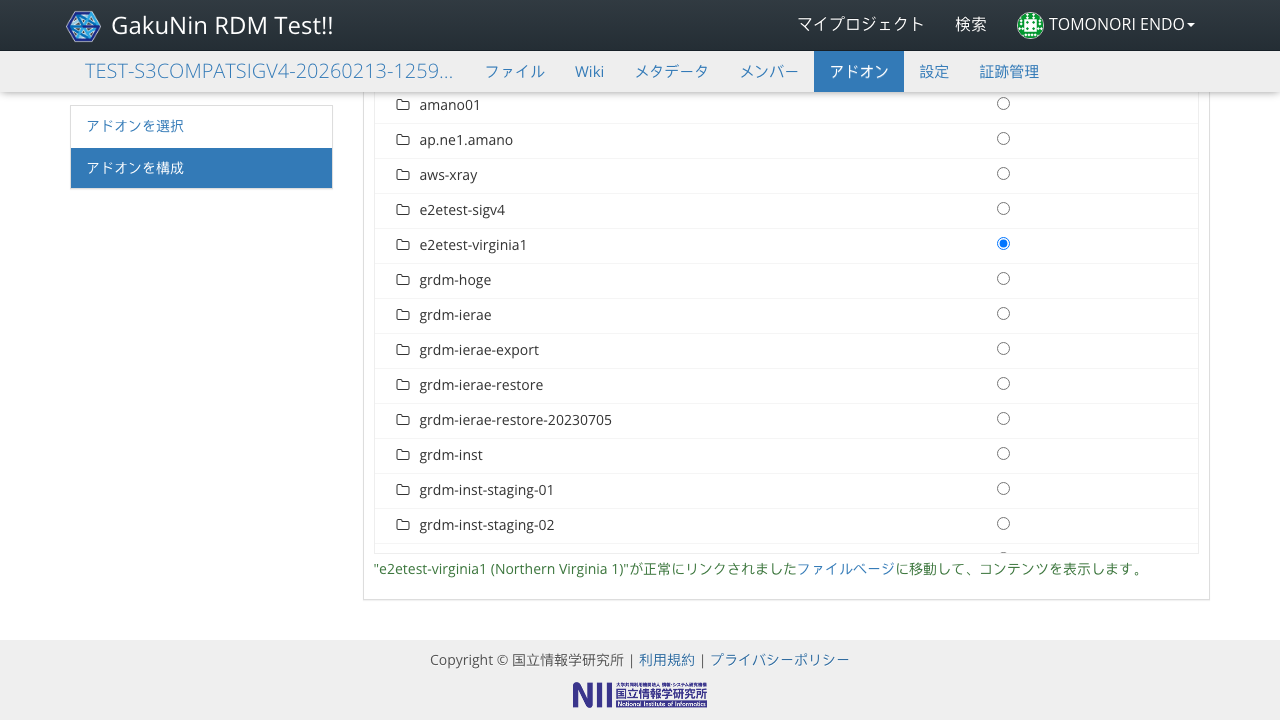

In [72]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(1)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)


## (実施対象の場合)テストバケット(2つ目)に1500個のファイルを作る

ファイル名は `NNNN` の形式とする。

In [77]:
# with open(os.path.join(work_dir, '.aws'), 'w') as f:
#     f.write(f'''
# export AWS_ACCESS_KEY_ID={s3_access_key_2}
# export AWS_SECRET_ACCESS_KEY={s3_secret_access_key_2}
# export AWS_ENDPOINT_URL={s3_endpoint_2}
# ''')
# # TODO
# !source {work_dir}/.aws && ~/aws/dist/aws s3api list-objects --bucket {s3_test_bucket_name_2}


In [78]:
# for i in range(1500):
#     filename = '{0:04d}'.format(i + 1)
#     !source {work_dir}/.aws && ~/aws/dist/aws s3api put-object --bucket {s3_test_bucket_name_2} --key {filename}


zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

...

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.tomonori/aws/dist/aws
zsh:1: no such file or directory: /Users/endo.to

## 「ファイルページ」リンクをクリックする

Start epoch: 1770957129.3257458 seconds


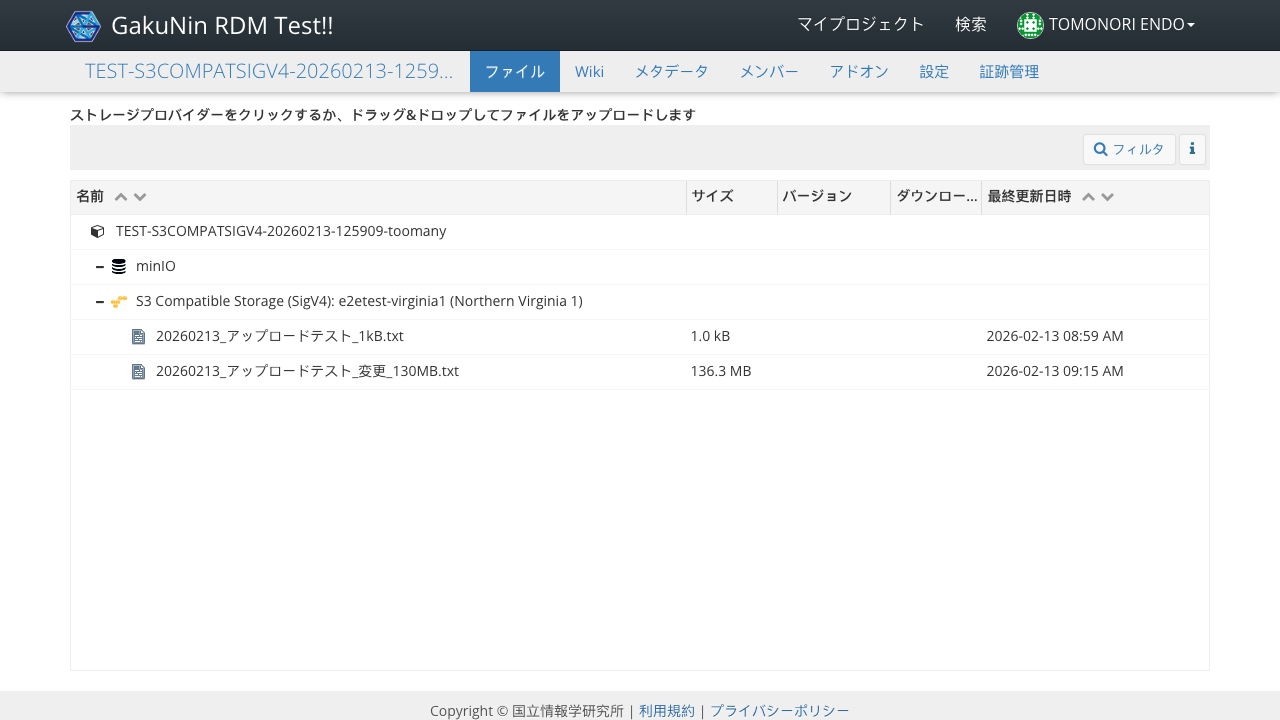

In [75]:
async def _step(page):
    try:
        await page.get_by_role("link", name="ファイルページ").click()
    except:
        print('Ignored')
        traceback.print_exc()
        await page.locator('//*[@id = "projectNavFiles"]//a').click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)


## (実施対象の場合)ファイルが 0001 〜 1500 まであることを確認する

999個よりあとは、スクロールによって読み込まれること

In [76]:
async def _step(page):
    if skip_too_many_files_check:
        return
    for i in range(1500):
        filename = '{0:04d}'.format(i + 1)
        await grdm.get_select_file_extension_locator(page, filename).scroll_into_view_if_needed()
        await page.evaluate("document.querySelector('#tb-tbody').scrollBy(0, 40)")

await run_pw(_step)


## プロジェクトを削除する

Start epoch: 1770957659.638112 seconds
Mitchell


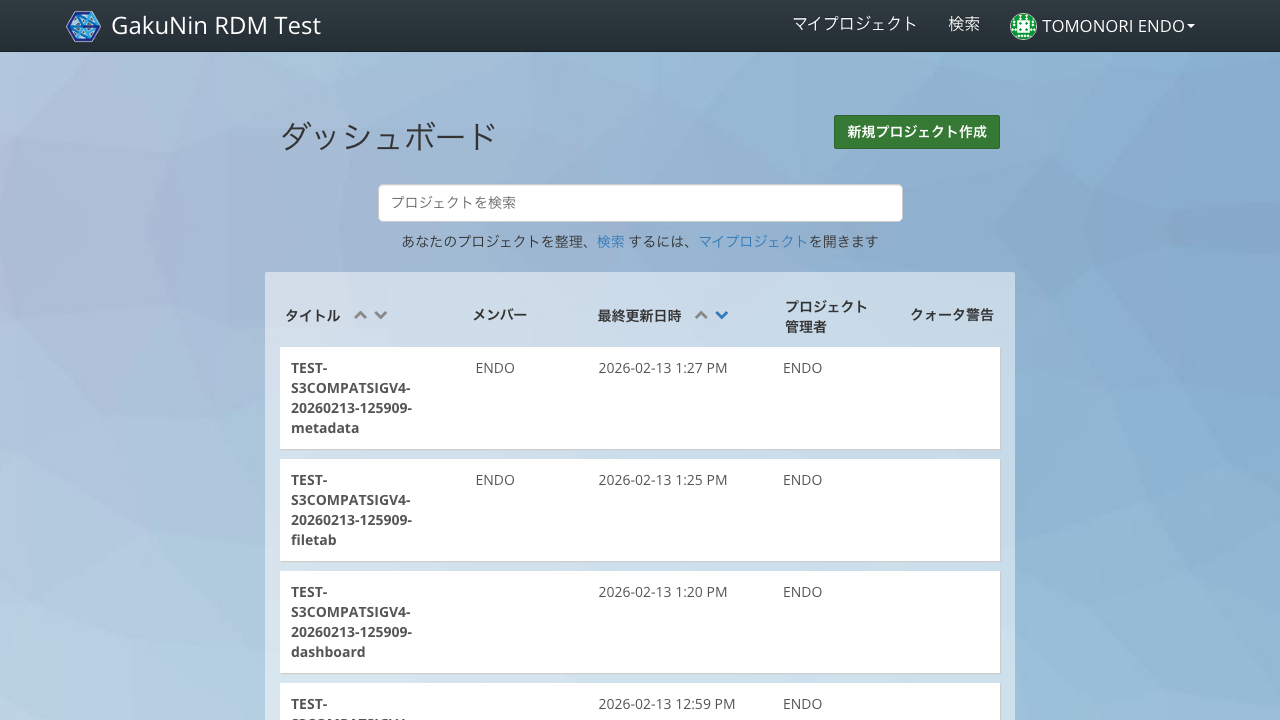

In [79]:
async def _step(page):
    await scripts.grdm.delete_project(page)

    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## ユーザーメニューから「設定」を選択する

Start epoch: 1770957869.054129 seconds


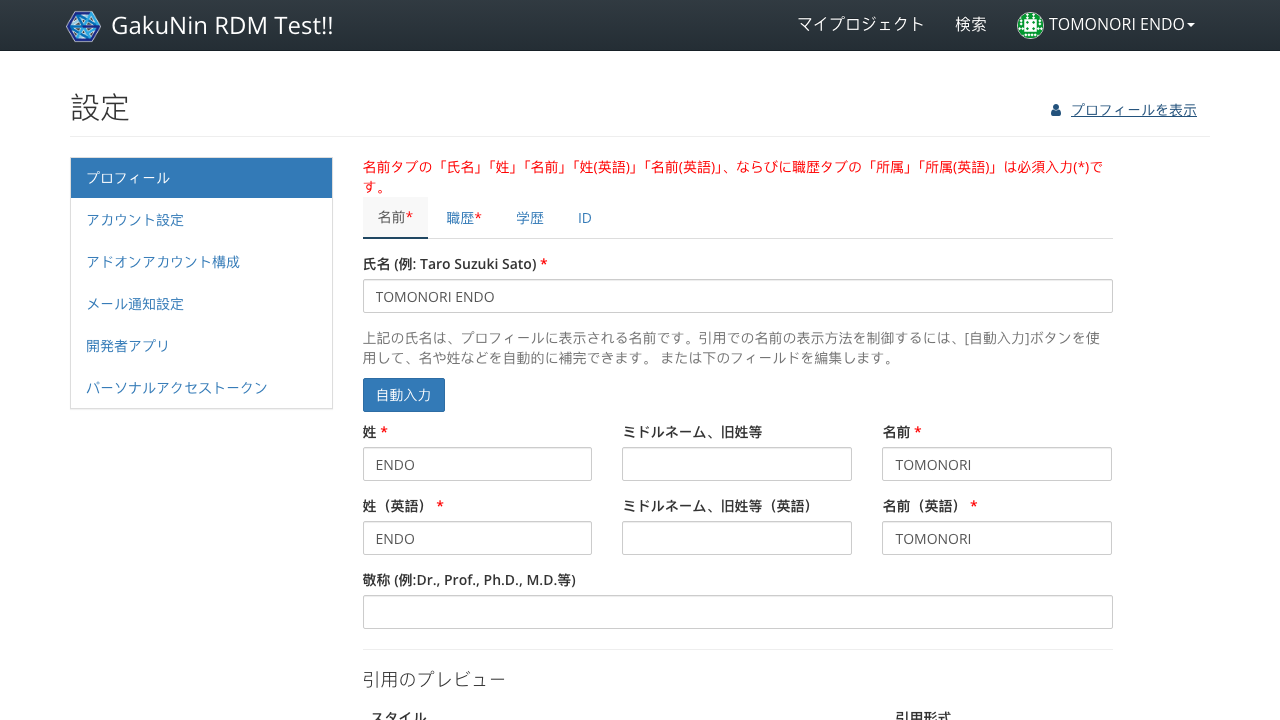

In [80]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@data-analytics-name="Settings"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンアカウント構成」を選択する

Start epoch: 1770957872.9790452 seconds


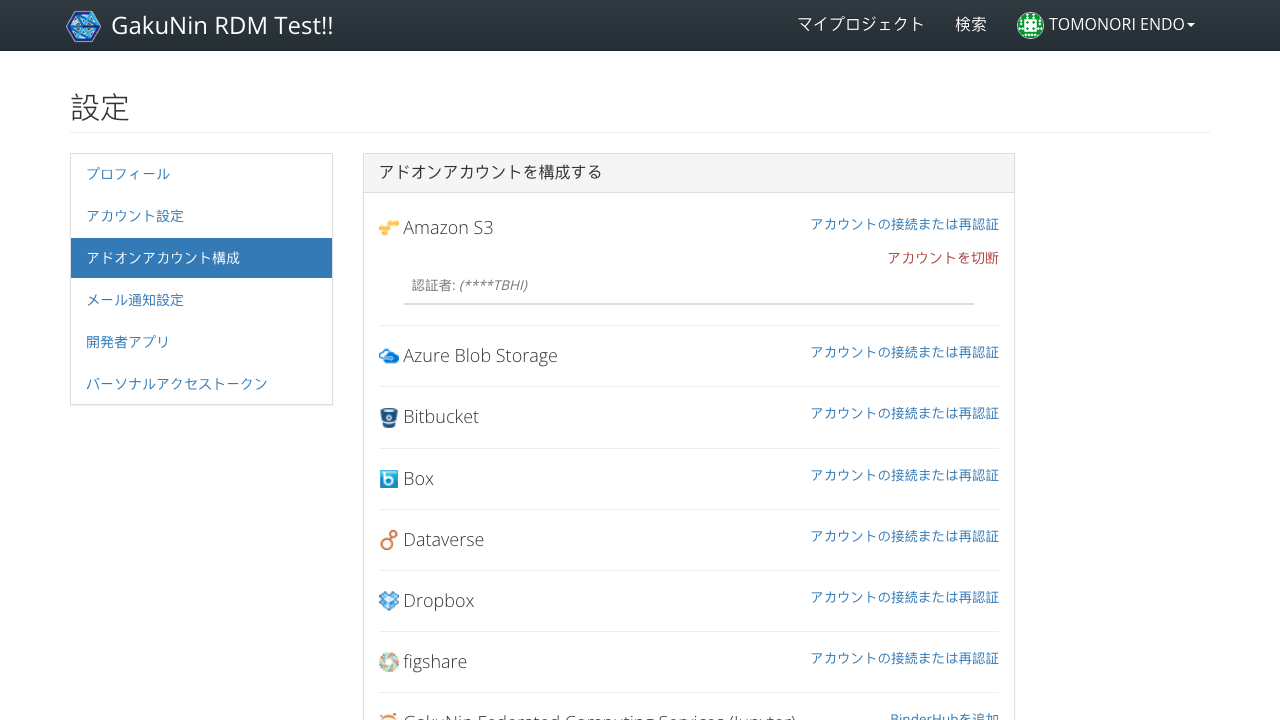

In [81]:
import traceback

async def _step(page):
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[@data-bind="text: properName" and text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(2, timeout=30000)

await run_pw(_step)


## 1つ目の「アカウントを切断」をクリックし、「Disconnect」をクリックする

Start epoch: 1770957876.6812558 seconds


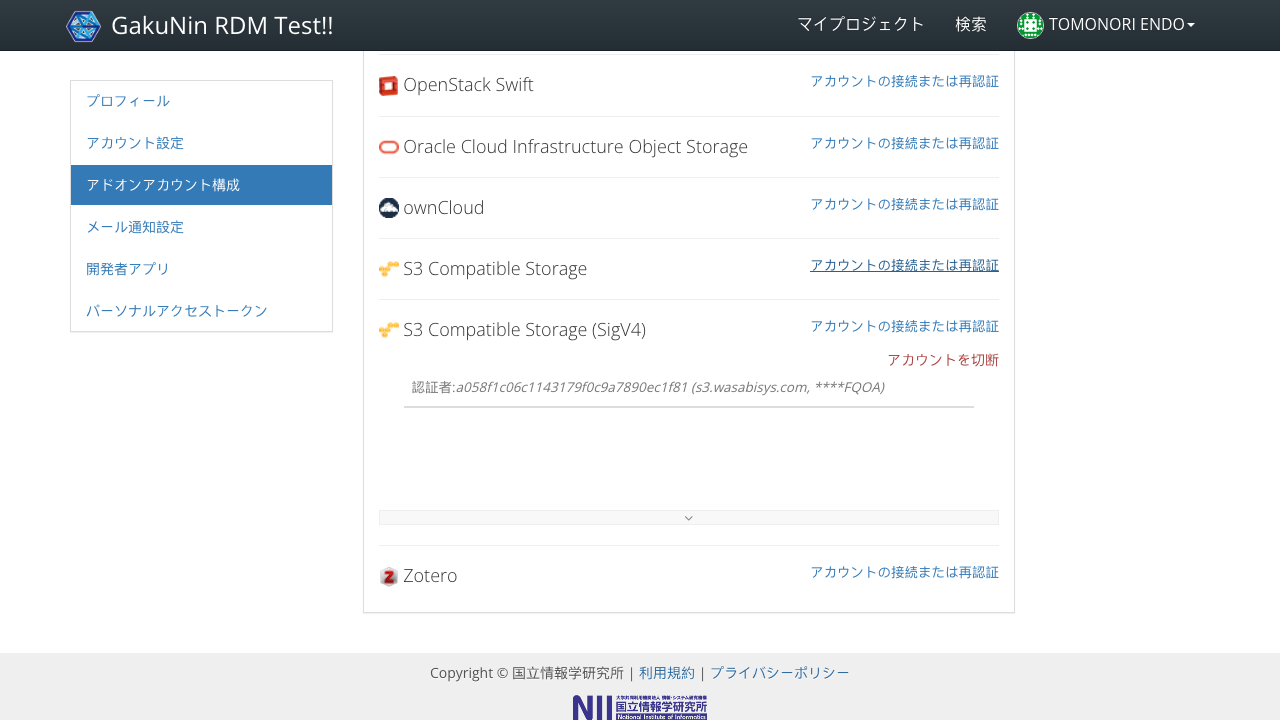

In [82]:
async def _step(page):
    await page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]').click()
    await page.locator('.bootbox-confirm .btn-danger').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(1, timeout=transition_timeout)

await run_pw(_step)


## 2つ目の「アカウントを切断」をクリックし、「Disconnect」をクリックする

Start epoch: 1770957880.581577 seconds


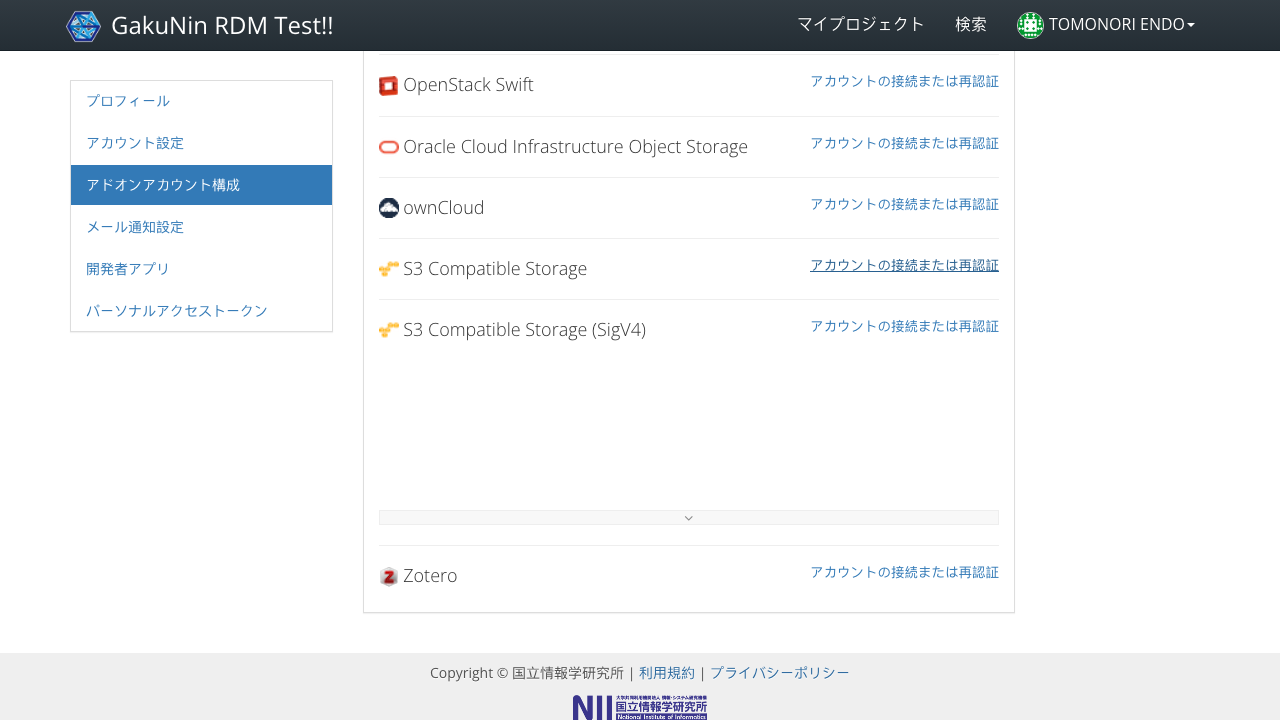

In [83]:
async def _step(page):
    await page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]').click()
    await page.locator('.bootbox-confirm .btn-danger').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)


終了処理を実施。

In [84]:
await finish_pw_context()


Video: /var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1/video-1.webm
HAR: /var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpgs6jmlt1/har.zip


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/endo.tomonori/Desktop/git/tishin-endou/RDM-e2e-test-nb/scripts/playwright.py", line 168, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpssqw1zey/videos/5cef0ee8343e24a37fbf1d1ca5df0d43.webm'


In [ ]:
!rm -fr {work_dir}
